In [1]:
# Copyright (c) 2025, TU Wien
# All rights reserved.

# THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
# AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
# IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE
# ARE DISCLAIMED. IN NO EVENT SHALL TU WIEN BE LIABLE FOR ANY DIRECT, INDIRECT,
# INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL DAMAGES (INCLUDING, BUT NOT
# LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR SERVICES; LOSS OF USE, DATA,
# OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER CAUSED AND ON ANY THEORY OF
# LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY, OR TORT (INCLUDING
# NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE OF THIS SOFTWARE,
# EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.

In [6]:
%pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]1/2 [shap]
Note: you may need to restart the kernel to use updated packages.


In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import tabulate
import pickle
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

from scat_data_science.data_io.ascat_readers import AscatH121DynSlope
from scat_data_science.data_io.lsm_readers import Era5
from scat_data_science.data_io.veg_readers import Modis_MOD15A2H

import shap

import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module=r"xgboost\.core"
)

import logging

current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_filename = f"model_logs_{current_time}.txt"

if not os.path.exists("logs"):
    os.makedirs("logs")
log_path = os.path.join("logs", log_filename)

# Clear any existing handlers to prevent duplicate or "zombie" logs
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(message)s',
    handlers=[
        logging.FileHandler(log_path),
        logging.StreamHandler()
    ],
    force=True
)



logging.info(f"Logging initialized. Saving to: {log_path}")


def add_lag_features(X, lag_days, lag_cols=None):
    """
    Add lagged versions of feature columns to X.
    
    Parameters
    ----------
    X : pd.DataFrame
        Feature DataFrame with a DatetimeIndex.
    lag_days : list of int
        List of lag offsets in days (e.g., [7, 14]).
    lag_cols : list of str, optional
        Columns to lag. Defaults to all columns in X.
    
    Returns
    -------
    pd.DataFrame
        X with additional lag columns appended.
    """
    if lag_cols is None:
        lag_cols = X.columns.tolist()
    
    lagged_frames = [X]
    
    for lag in lag_days:
        shifted = X[lag_cols].shift(freq=pd.Timedelta(days=lag))
        # Reindex to original timestamps using nearest match within tolerance
        shifted = shifted.reindex(X.index, method="nearest", tolerance=pd.Timedelta(days=2))
        shifted.columns = [f"{col}_lag{lag}" for col in lag_cols]
        lagged_frames.append(shifted)
    
    return pd.concat(lagged_frames, axis=1)

def format_date(xticks, pos=None):
    """
    Format date of axis.

    Parameters
    ----------
    xticks : numpy.ndarray
        xticks
    """
    dt = mdates.num2date(xticks)

    if dt.month == 7:
        fmt = "%Y"
        # fmt = "%m\n%Y"
        return f"{dt.strftime(fmt)}"
    else:
        return ""
        # fmt = "%m"
        # return f"{dt.strftime(fmt)}"


def format_date_month(xticks, pos=None):
    """
    Format date of axis.

    Parameters
    ----------
    xticks : numpy.ndarray
        xticks
    """
    dt = mdates.num2date(xticks)

    if dt.month == 1:
        fmt = "%b\n%Y"
        return f"{dt.strftime(fmt)}"
    else:
        fmt = "%b"
        return f"{dt.strftime(fmt)}"


def format_axis(ax):
    """Format axis"""
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mticker.NullFormatter())

    ax.xaxis.set_minor_locator(mdates.MonthLocator(range(1, 13, 3)))
    ax.xaxis.set_minor_formatter(mticker.FuncFormatter(format_date))

    ax.grid(True)


def format_axis_month(ax):
    """Format axis"""
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    ax.tick_params(axis='x', which='major', labelsize=9)
    ax.grid(True)


def read_data(gpi):
    """Simple reader."""
    read_bulk = False
    sampling = 12.5

    ascat = AscatH121DynSlope(read_bulk=read_bulk)
    era5 = Era5(read_bulk=read_bulk)
    modis = Modis_MOD15A2H()

    ts_ascat = ascat.read(gpi)
    lon, lat = ascat.grid.gpi2lonlat(gpi)
    ts_era5 = era5.read(lon, lat)
    ts_veg = modis.read(lon, lat)

    tolerance = pd.Timedelta("6h")
    ts = pd.merge_asof(ts_ascat,
                       ts_era5,
                       left_index=True,
                       right_index=True,
                       tolerance=tolerance,
                       direction="nearest")

    tolerance = pd.Timedelta("8D")
    ts = pd.merge_asof(ts,
                       ts_veg,
                       left_index=True,
                       right_index=True,
                       tolerance=tolerance,
                       direction="nearest")

    lon, lat = ascat.grid.gpi2lonlat(gpi)

    loc_info = f"GPI: {gpi} FibGrid: {sampling} km\n Longitude: {lon:3.3f} Latitude: {lat:3.3f}"
    gpi_info = {"gpi": gpi, "FibGrid": sampling, "lon": lon, "lat": lat}
    return ts, loc_info, gpi_info


def simple_plot_old(ts, loc_info):
    """Simple time series plots."""

    figsize = (12, 10)
    fig, ax = plt.subplots(6, 1, figsize=figsize, sharex=True)
    fig.suptitle(loc_info)

    kwargs = {
        "marker": "o",
        "ls": "none",
        "fillstyle": "none",
        "markersize": 4,
        "alpha": 0.5
    }

    ax[0].plot(ts["slope40"], label="ASCAT slope40", color="C01", **kwargs)
    ax[0].set_ylabel("Slope [dB deg$^{-1}$]")

    ax[1].plot(ts["backscatter40"],
               label="ASCAT $\\sigma^{{0}} (40^{\\circ})$ (backscatter40)",
               **kwargs)
    ax[1].set_ylabel("Backscatter [dB]")

    ax[2].plot(ts["swvl1"], label="ERA5 Soil moisture (swvl1)", **kwargs)
    ax[2].set_ylabel("Vol. SM [m$^3\\,$m$^{-3}$]")

    ax[3].plot(ts["stl1"], label="ERA5 Surface temperature (stl1)", **kwargs)
    ax[3].set_ylabel("Temperature [$^{\\circ}$C]")

    ax[4].plot(ts["LAI"], label="Modis LAI (MOD15A2H)", **kwargs)
    ax[4].set_ylabel("LAI [m$^2\\,$m$^{-2}$]")

    ax[5].plot(ts["fPAR"], label="Modis fPAR (MOD15A2H)", **kwargs)
    ax[5].set_ylabel("fPAR [-]")

    for i in range(ax.size):
        ax[i].legend()
        format_axis(ax[i])

    plt.tight_layout()


def simple_plot(ts, loc_info, cols):
    """Simple time series plots."""

    figsize = (12, 2*len(cols))
    fig, ax = plt.subplots(len(cols), 1, figsize=figsize, sharex=True)
    fig.suptitle(loc_info)
    if len(cols) == 1:
        ax = [ax]

    kwargs = {
        "marker": "o",
        "ls": "none",
        "fillstyle": "none",
        "markersize": 4,
        "alpha": 0.5
    }

    for i in range(len(cols)):
        ax[i].plot(ts[cols[i]], label=cols[i], **kwargs)
        ax[i].set_ylabel(cols[i])

    for i in range(len(ax)):
        ax[i].legend()
        format_axis(ax[i])

    plt.tight_layout()


def prediction_plot(model_name, target_column, y_train_final, y_test_final, y_pred_series, save_path=None):
    plt.figure(figsize=(12, 6))
    plt.plot(y_train_final.index, y_train_final, label=f"ASCAT {target_column} (Training)", color="blue", alpha=0.7)
    plt.plot(y_test_final.index, y_test_final, label=f"ASCAT {target_column} (Actual Test)", color="green", marker="o", markersize=3, linestyle="none")
    plt.plot(y_pred_series.index, y_pred_series, label=f"{model_name} Prediction", color="orange", linestyle="--", marker="x", markersize=3)
    plt.title(f"{model_name} Predictions vs. Actuals for {loc_info.splitlines()}")
    plt.ylabel(f"{target_column}")
    plt.xlabel("Date")
    plt.legend()
    format_axis_month(plt.gca())
    plt.grid(True)
    plt.tight_layout()

    # --- SAVE LOGIC ---
    if save_path:
        # Extract the directory from the full path
        directory = os.path.dirname(save_path)
        # Create folder if it doesn't exist
        if directory and not os.path.exists(directory):
            os.makedirs(directory, exist_ok=True)

        plt.savefig(save_path)
        print(f"Plot saved to: {save_path}")

    plt.show()


def residual_plot(model_name, residuals, save_path=None):
    plt.figure(figsize=(12, 4))
    plt.plot(residuals.index, residuals, label="Residuals", color="purple", marker=".", linestyle="none", alpha=0.6)
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
    plt.title(f"{model_name} Residuals for {loc_info.splitlines()}")
    plt.ylabel("Residuals")
    plt.xlabel("Date")
    plt.legend()
    format_axis_month(plt.gca())
    plt.grid(True)
    plt.tight_layout()

    # --- SAVE LOGIC ---
    if save_path:
        directory = os.path.dirname(save_path)
        if directory and not os.path.exists(directory):
            os.makedirs(directory, exist_ok=True)

        plt.savefig(save_path)
        print(f"Residual plot saved to: {save_path}")

    plt.show()


def performance_table(results):
    logging.info("\n--- Summary of Model Test Set Performance ---")

    performance_data = []
    for model_name, metrics in results.items():
        performance_data.append({
            "Model": model_name,
            "RMSE": metrics["test_rmse"],
            "MAE": metrics["test_mae"],
            "R2": metrics["test_r2"],
            "Temporal Correlation": metrics["test_temporal_correlation"]
        })

    df_performance = pd.DataFrame(performance_data)
    df_performance = df_performance.set_index("Model")
    df_performance = df_performance.apply(lambda x: x.map('{:.5f}'.format))
    logging.info(df_performance)
    print(df_performance.to_markdown(numalign="left", stralign="left"))


def feature_importance_table(results):
    logging.info("\n--- Summary of Feature Importance (Mean Decrease in Score) ---")
    all_importances = {
        model: results[model]["feature_importance"]
        for model in results
    }
    df_importances = pd.DataFrame.from_dict(all_importances)
    if df_importances.shape[1] > 0:
        sort_column = df_importances.columns[0]
        df_importances = df_importances.sort_values(by=sort_column, ascending=False)
    else:
        print("No importance data available to display.")
    df_importances_formatted = df_importances.apply(lambda x: x.map('{:.4f}'.format))
    logging.info(df_importances_formatted)
    print(df_importances_formatted.to_markdown(numalign="left", stralign="left"))


def get_grid_levels(gpi):
    """ retrieves grid_point with distance ~60-70km and ~130-140km from given gpi"""

    cell = ascat.grid.gpi2cell(gpi)
    grid_points_data = ascat.grid.grid_points_for_cell(cell)
    data = {"grid_point": grid_points_data[0], "lon": grid_points_data[1], "lat": grid_points_data[2], "distance": None}
    df = pd.DataFrame(data)

    orig_coords = (df.iloc[0]["lat"], df.iloc[0]["lon"])
    grid_levels = {"level_0": {"grid_point": df.iloc[0]["grid_point"], "lon": df.iloc[0]["lon"], "lat": df.iloc[0]["lat"], "distance": 0}}

    for index, cell_grid in df.iterrows():
        distance = geodesic(orig_coords, (cell_grid["lat"], cell_grid["lon"])).km
        if distance > 60 and distance < 70:
            if not grid_levels.get("level_1"):
                grid_levels["level_1"] = {"grid_point": cell_grid["grid_point"], "lon": cell_grid["lon"], "lat": cell_grid["lat"], "distance": distance}
        elif distance > 130 and distance < 140:
            if not grid_levels.get("level_2"):
                grid_levels["level_2"] = {"grid_point": cell_grid["grid_point"], "lon": cell_grid["lon"], "lat": cell_grid["lat"], "distance": distance}
    return grid_levels


models = {
    "XGBRegressor": {
        "model": XGBRegressor(random_state=42, eval_metric='rmse', objective='reg:squarederror', n_jobs=-1),
        "params": {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(3, 10),
            'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
            'subsample': Real(0.6, 1.0),
            'colsample_bytree': Real(0.6, 1.0),
            'reg_alpha': Real(1e-6, 10.0, prior='log-uniform'),
            'reg_lambda': Real(1e-6, 10.0, prior='log-uniform'),
        }
    }
}

2026-03-16 21:56:47,549 - Logging initialized. Saving to: logs/model_logs_2026-03-16_21-56-47.txt


2026-03-16 21:56:52,257 - Modelling curvature40
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 21:56:57,002 - gpi: 2891016, lat: -14.444256782531738, lon: 132.8800048828125
2026-03-16 21:56:57,014 - Training data size: 7040
2026-03-16 21:56:57,014 - Testing data size: 1761
2026-03-16 21:56:57,018 - 
--- Baseline Model Performance ---
2026-03-16 21:56:57,024 - 
Climatology Model (Monthly Average):
2026-03-16 21:56:57,025 -   RMSE: 0.00072
2026-03-16 21:56:57,025 -   MAE: 0.00062
2026-03-16 21:56:57,025 -   R2: -0.93885
2026-03-16 21:56:57,026 -   Temporal Correlation: 0.66513
2026-03-16 21:56:57,028 - 
Random Noise Baseline:
2026-03-16 21:56:57,029 -   RMSE: 0.00072
2026-03-16 21:56:57,029 -   MAE: 0.00058
2026-03-16 21:56:57,029 -   R2: -0.94304
2026-03-16 21:56:57,030 -   Temporal C

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2891016/gpi_curvature40.png


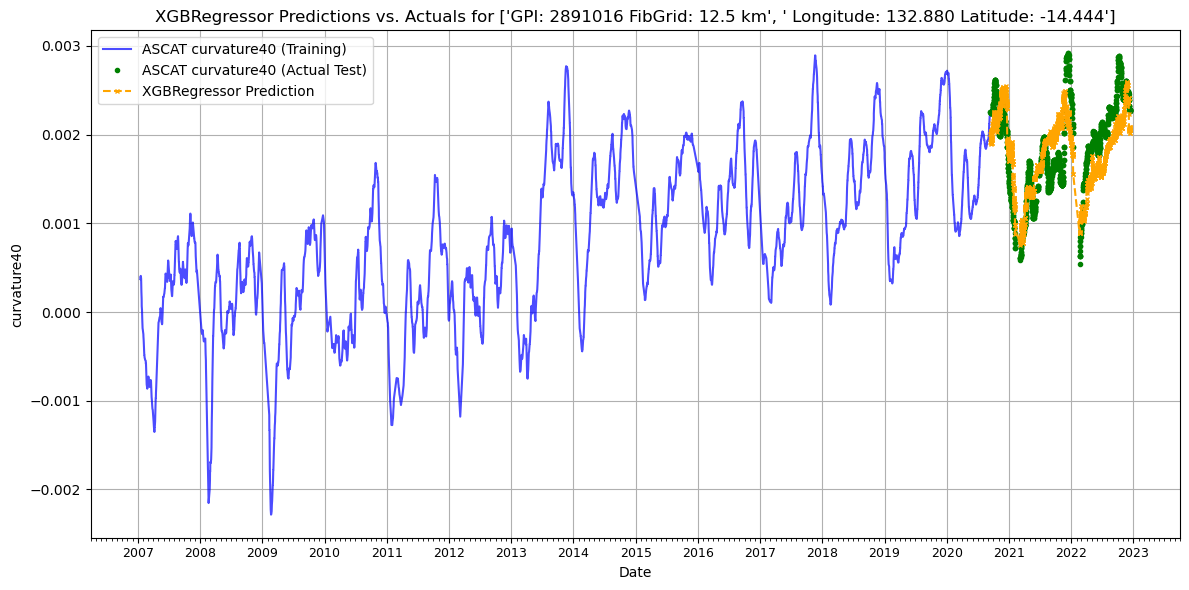

2026-03-16 22:00:30,025 - Starting expanding window forecast for 1761 points...
2026-03-16 22:00:48,006 - -- 6% done
2026-03-16 22:01:03,737 - -- 11% done
2026-03-16 22:01:22,589 - -- 17% done
2026-03-16 22:01:41,795 - -- 23% done
2026-03-16 22:01:58,411 - -- 28% done
2026-03-16 22:02:17,904 - -- 34% done
2026-03-16 22:02:37,552 - -- 40% done
2026-03-16 22:02:57,057 - -- 45% done
2026-03-16 22:03:16,775 - -- 51% done
2026-03-16 22:03:36,657 - -- 57% done
2026-03-16 22:03:56,543 - -- 62% done
2026-03-16 22:04:16,452 - -- 68% done
2026-03-16 22:04:36,398 - -- 74% done
2026-03-16 22:04:56,482 - -- 80% done
2026-03-16 22:05:16,539 - -- 85% done
2026-03-16 22:05:34,603 - -- 91% done
2026-03-16 22:05:51,546 - -- 97% done
2026-03-16 22:06:03,854 - -- 100% done
2026-03-16 22:06:03,864 - Expanding window predictions saved to ./images/curvature_no_backscatter/lagged/Australia_2891016/gpi_2891016_expanding_window_predictions.pkl


Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2891016/gpi_curvature40_expanding_window.png


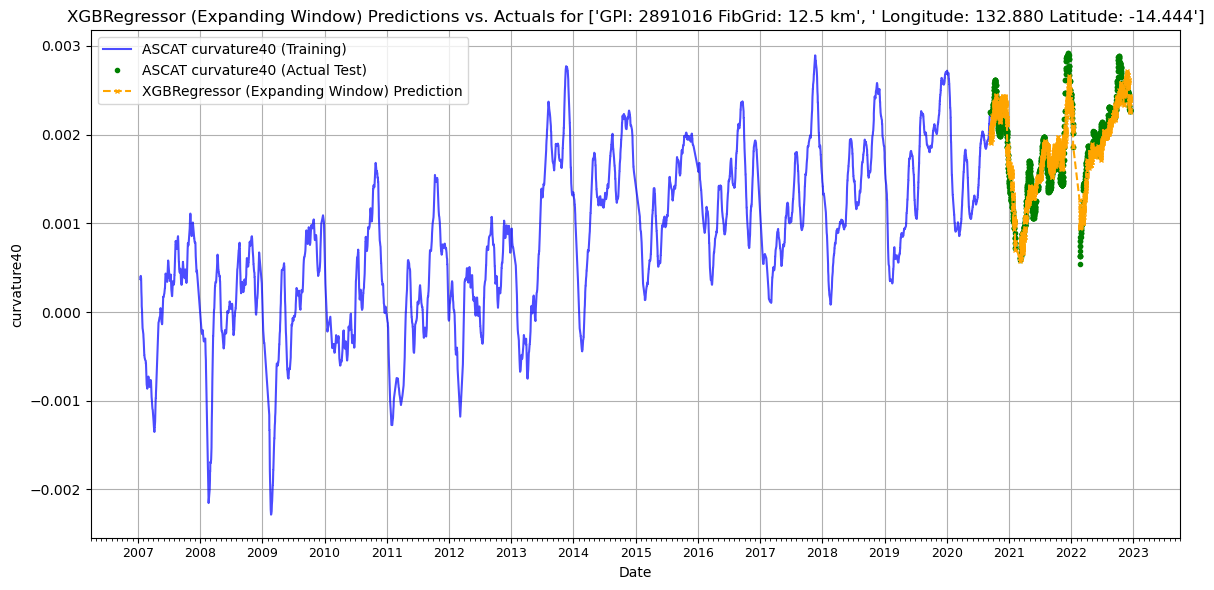

2026-03-16 22:06:04,571 - 
Final Performance:
2026-03-16 22:06:04,572 - RMSE: 0.00020 | MAE: 0.00016 | R2: 0.84519
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 22:06:09,555 - gpi: 2866040, lat: -15.346562385559082, lon: 126.794921875
2026-03-16 22:06:09,586 - Training data size: 7775
2026-03-16 22:06:09,587 - Testing data size: 1944
2026-03-16 22:06:09,591 - 
--- Baseline Model Performance ---
2026-03-16 22:06:09,597 - 
Climatology Model (Monthly Average):
2026-03-16 22:06:09,598 -   RMSE: 0.00054
2026-03-16 22:06:09,598 -   MAE: 0.00038
2026-03-16 22:06:09,599 -   R2: 0.83165
2026-03-16 22:06:09,599 -   Temporal Correlation: 0.92292
2026-03-16 22:06:09,602 - 
Random Noise Baseline:
2026-03-16 22:06:09,602 -   RMSE: 0.00183
2026-03-16 22:06:09,602 -   MAE: 0.00142
2026-03-16 22:06:

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2866040/gpi_curvature40.png


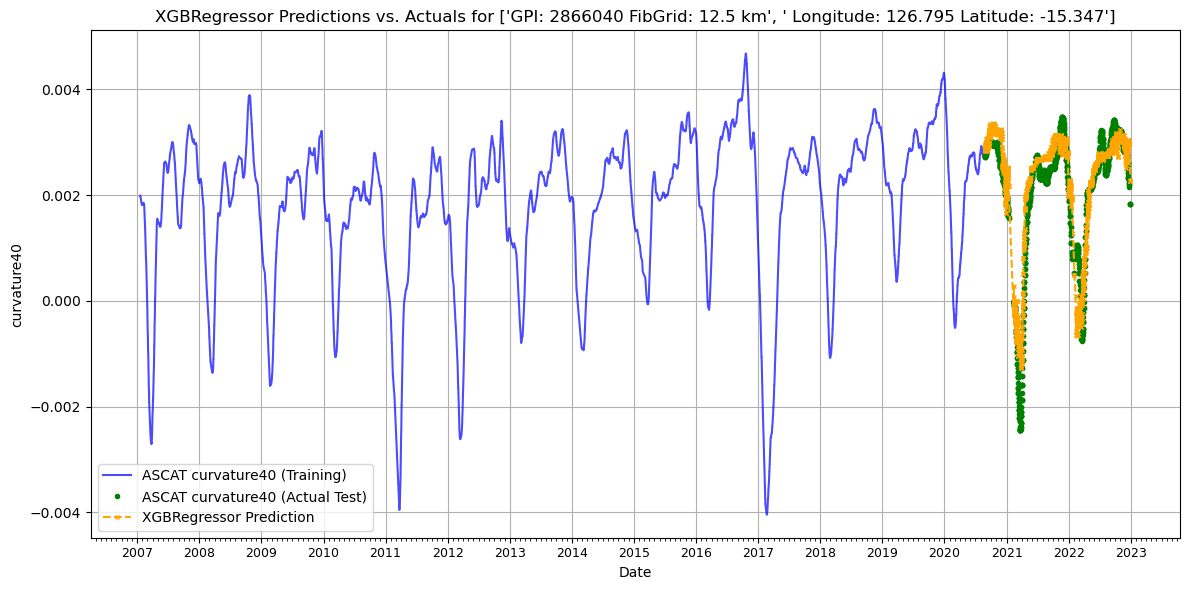

2026-03-16 22:09:49,429 - Starting expanding window forecast for 1944 points...
2026-03-16 22:09:56,759 - -- 5% done
2026-03-16 22:10:04,202 - -- 10% done
2026-03-16 22:10:11,593 - -- 15% done
2026-03-16 22:10:19,019 - -- 21% done
2026-03-16 22:10:26,316 - -- 26% done
2026-03-16 22:10:33,353 - -- 31% done
2026-03-16 22:10:40,543 - -- 36% done
2026-03-16 22:10:47,448 - -- 41% done
2026-03-16 22:10:53,907 - -- 46% done
2026-03-16 22:11:00,418 - -- 51% done
2026-03-16 22:11:07,034 - -- 57% done
2026-03-16 22:11:13,594 - -- 62% done
2026-03-16 22:11:20,146 - -- 67% done
2026-03-16 22:11:27,315 - -- 72% done
2026-03-16 22:11:35,045 - -- 77% done
2026-03-16 22:11:42,780 - -- 82% done
2026-03-16 22:11:50,574 - -- 87% done
2026-03-16 22:11:58,399 - -- 93% done
2026-03-16 22:12:06,219 - -- 98% done
2026-03-16 22:12:09,774 - -- 100% done
2026-03-16 22:12:09,785 - Expanding window predictions saved to ./images/curvature_no_backscatter/lagged/Australia_2866040/gpi_2866040_expanding_window_predicti

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2866040/gpi_curvature40_expanding_window.png


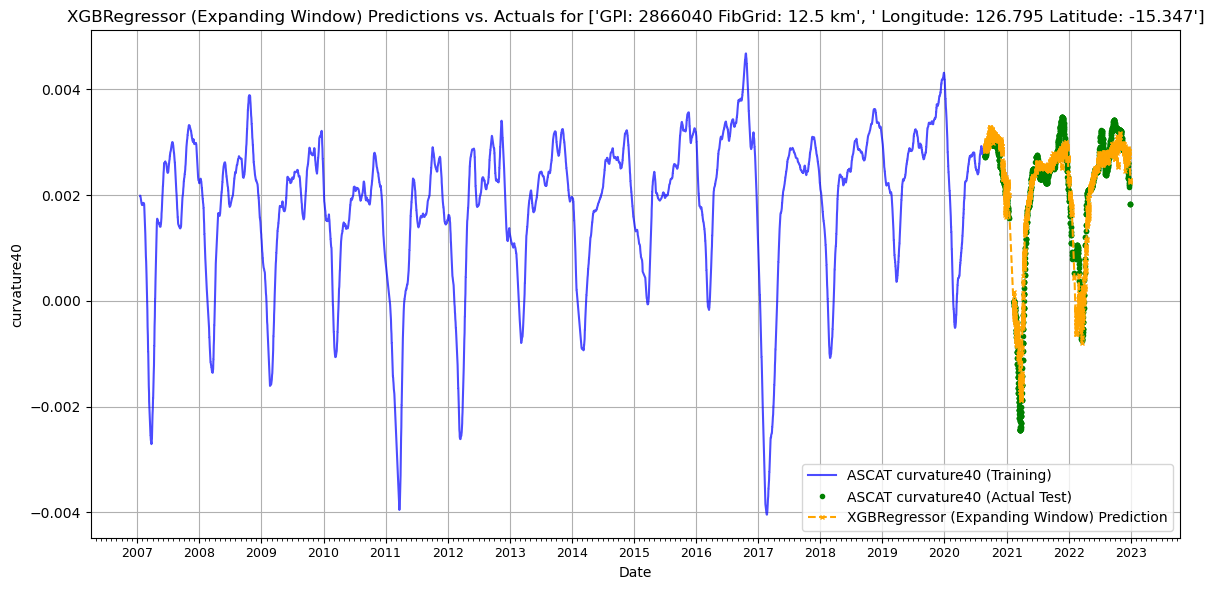

2026-03-16 22:12:10,610 - 
Final Performance:
2026-03-16 22:12:10,610 - RMSE: 0.00037 | MAE: 0.00027 | R2: 0.92060
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 22:12:15,146 - gpi: 2831296, lat: -16.608083724975586, lon: 136.549072265625
2026-03-16 22:12:15,158 - Training data size: 7274
2026-03-16 22:12:15,158 - Testing data size: 1819
2026-03-16 22:12:15,162 - 
--- Baseline Model Performance ---
2026-03-16 22:12:15,168 - 
Climatology Model (Monthly Average):
2026-03-16 22:12:15,168 -   RMSE: 0.00056
2026-03-16 22:12:15,169 -   MAE: 0.00044
2026-03-16 22:12:15,169 -   R2: 0.41131
2026-03-16 22:12:15,169 -   Temporal Correlation: 0.67064
2026-03-16 22:12:15,171 - 
Random Noise Baseline:
2026-03-16 22:12:15,172 -   RMSE: 0.00101
2026-03-16 22:12:15,172 -   MAE: 0.00080
2026-03-16 22:

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2831296/gpi_curvature40.png


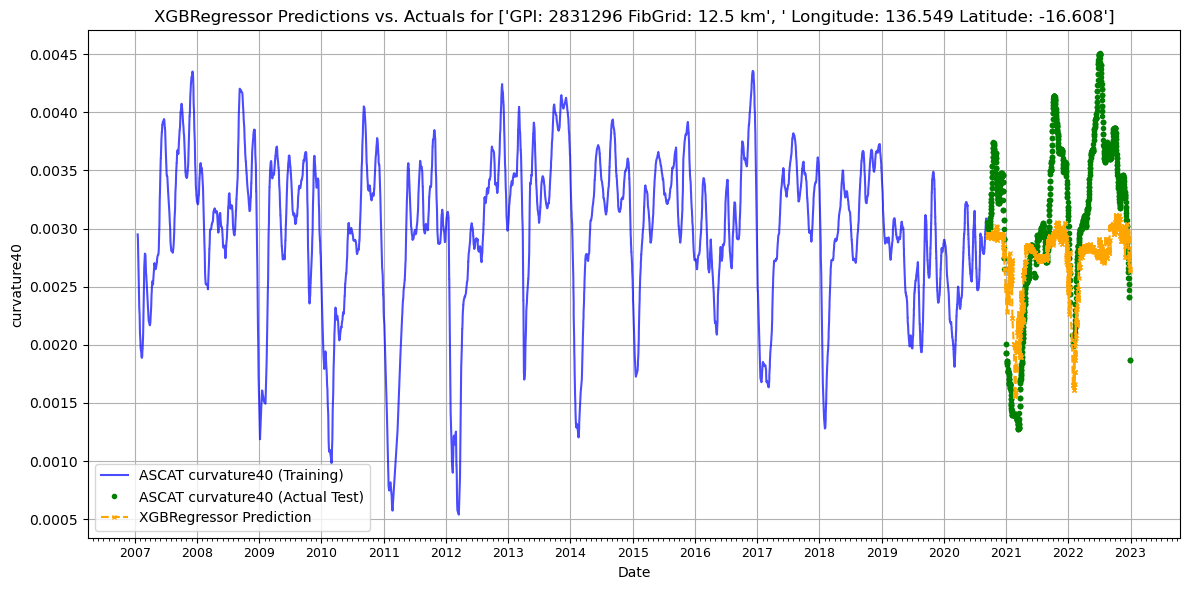

2026-03-16 22:16:06,667 - Starting expanding window forecast for 1819 points...
2026-03-16 22:16:24,152 - -- 5% done
2026-03-16 22:16:41,469 - -- 11% done
2026-03-16 22:16:58,991 - -- 16% done
2026-03-16 22:17:16,338 - -- 22% done
2026-03-16 22:17:33,909 - -- 27% done
2026-03-16 22:17:51,624 - -- 33% done
2026-03-16 22:18:09,445 - -- 38% done
2026-03-16 22:18:27,258 - -- 44% done
2026-03-16 22:18:45,149 - -- 49% done
2026-03-16 22:19:02,983 - -- 55% done
2026-03-16 22:19:20,880 - -- 60% done
2026-03-16 22:19:38,732 - -- 66% done
2026-03-16 22:19:56,558 - -- 71% done
2026-03-16 22:20:14,674 - -- 77% done
2026-03-16 22:20:32,777 - -- 82% done
2026-03-16 22:20:51,049 - -- 88% done
2026-03-16 22:21:09,653 - -- 93% done
2026-03-16 22:21:27,988 - -- 99% done
2026-03-16 22:21:31,674 - -- 100% done
2026-03-16 22:21:31,916 - Expanding window predictions saved to ./images/curvature_no_backscatter/lagged/Australia_2831296/gpi_2831296_expanding_window_predictions.pkl


Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2831296/gpi_curvature40_expanding_window.png


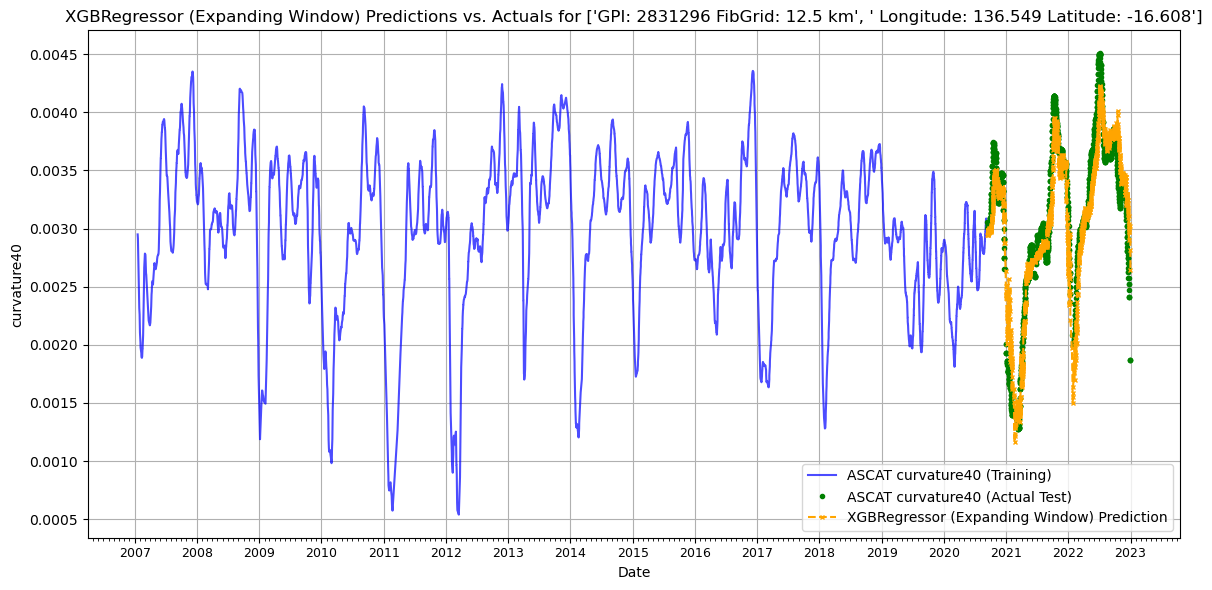

2026-03-16 22:21:32,659 - 
Final Performance:
2026-03-16 22:21:32,659 - RMSE: 0.00024 | MAE: 0.00019 | R2: 0.89136
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 22:21:37,075 - gpi: 2912599, lat: -13.667365074157715, lon: 142.8085174560547
2026-03-16 22:21:37,087 - Training data size: 7480
2026-03-16 22:21:37,088 - Testing data size: 1871
2026-03-16 22:21:37,092 - 
--- Baseline Model Performance ---
2026-03-16 22:21:37,098 - 
Climatology Model (Monthly Average):
2026-03-16 22:21:37,098 -   RMSE: 0.00032
2026-03-16 22:21:37,099 -   MAE: 0.00024
2026-03-16 22:21:37,099 -   R2: 0.81453
2026-03-16 22:21:37,099 -   Temporal Correlation: 0.90673
2026-03-16 22:21:37,101 - 
Random Noise Baseline:
2026-03-16 22:21:37,102 -   RMSE: 0.00102
2026-03-16 22:21:37,102 -   MAE: 0.00082
2026-03-16 22

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2912599/gpi_curvature40.png


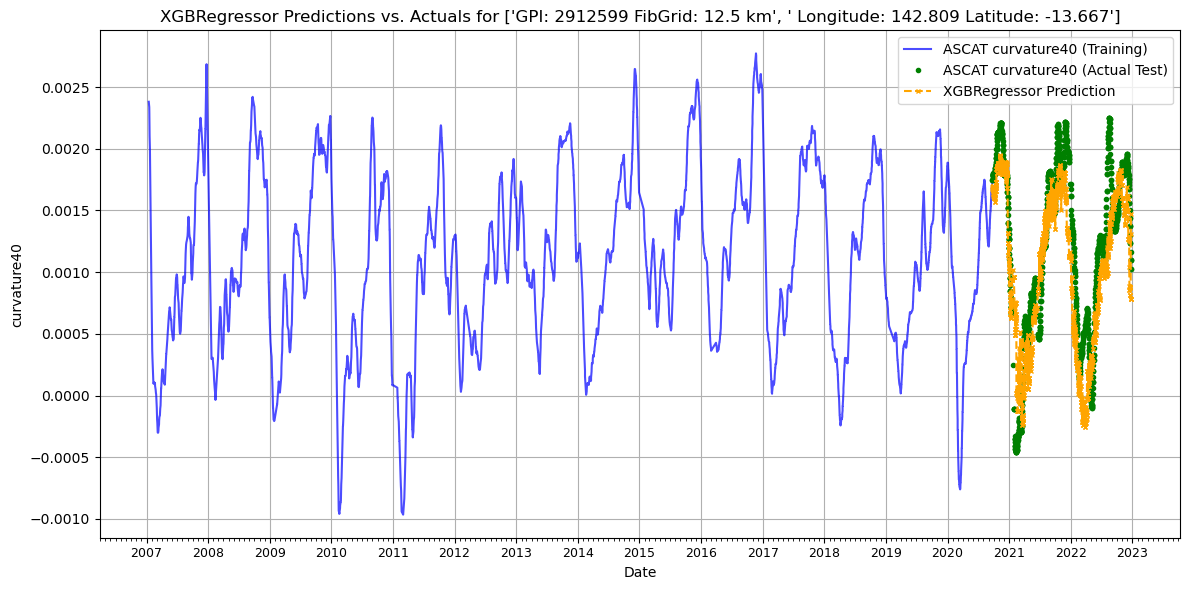

2026-03-16 22:25:02,277 - Starting expanding window forecast for 1871 points...
2026-03-16 22:25:08,177 - -- 5% done
2026-03-16 22:25:14,189 - -- 11% done
2026-03-16 22:25:20,197 - -- 16% done
2026-03-16 22:25:26,273 - -- 21% done
2026-03-16 22:25:32,340 - -- 27% done
2026-03-16 22:25:38,395 - -- 32% done
2026-03-16 22:25:44,510 - -- 37% done
2026-03-16 22:25:50,738 - -- 43% done
2026-03-16 22:25:57,007 - -- 48% done
2026-03-16 22:26:03,288 - -- 53% done
2026-03-16 22:26:09,599 - -- 59% done
2026-03-16 22:26:15,938 - -- 64% done
2026-03-16 22:26:22,310 - -- 69% done
2026-03-16 22:26:28,752 - -- 75% done
2026-03-16 22:26:34,610 - -- 80% done
2026-03-16 22:26:40,934 - -- 86% done
2026-03-16 22:26:47,593 - -- 91% done
2026-03-16 22:26:54,289 - -- 96% done
2026-03-16 22:26:59,080 - -- 100% done
2026-03-16 22:26:59,089 - Expanding window predictions saved to ./images/curvature_no_backscatter/lagged/Australia_2912599/gpi_2912599_expanding_window_predictions.pkl


Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2912599/gpi_curvature40_expanding_window.png


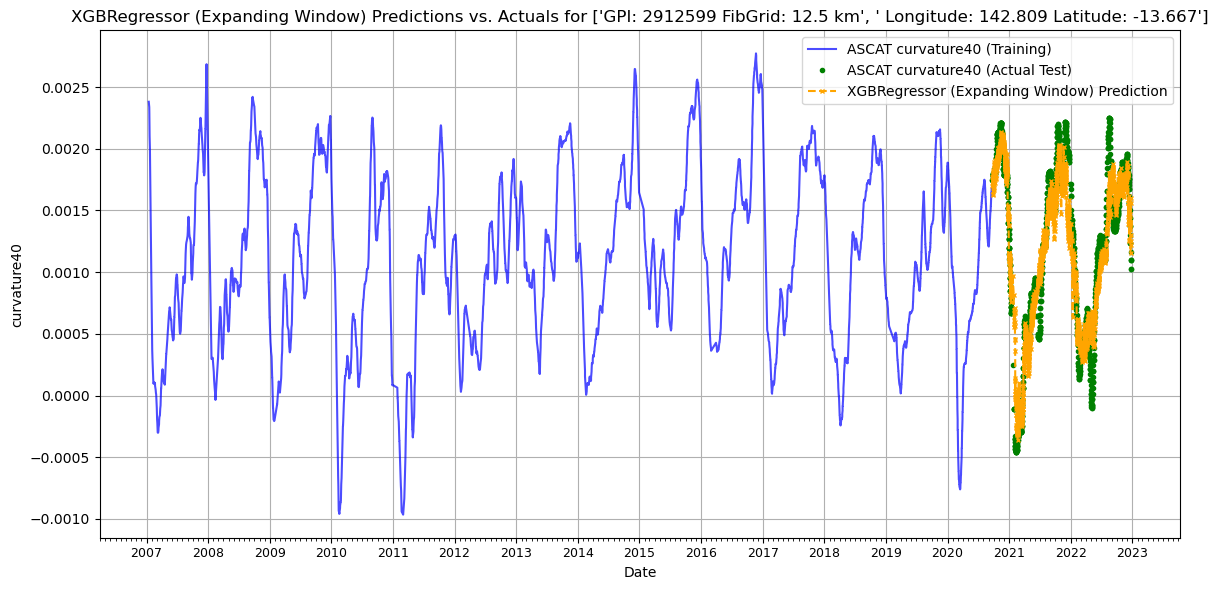

2026-03-16 22:26:59,790 - 
Final Performance:
2026-03-16 22:26:59,791 - RMSE: 0.00024 | MAE: 0.00018 | R2: 0.89328
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 22:27:04,620 - gpi: 2808396, lat: -17.443904876708984, lon: 144.3458251953125
2026-03-16 22:27:04,642 - Training data size: 8236
2026-03-16 22:27:04,643 - Testing data size: 2059
2026-03-16 22:27:04,647 - 
--- Baseline Model Performance ---
2026-03-16 22:27:04,653 - 
Climatology Model (Monthly Average):
2026-03-16 22:27:04,653 -   RMSE: 0.00072
2026-03-16 22:27:04,654 -   MAE: 0.00059
2026-03-16 22:27:04,654 -   R2: -1.78641
2026-03-16 22:27:04,655 -   Temporal Correlation: 0.25575
2026-03-16 22:27:04,657 - 
Random Noise Baseline:
2026-03-16 22:27:04,657 -   RMSE: 0.00061
2026-03-16 22:27:04,658 -   MAE: 0.00049
2026-03-16 2

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2808396/gpi_curvature40.png


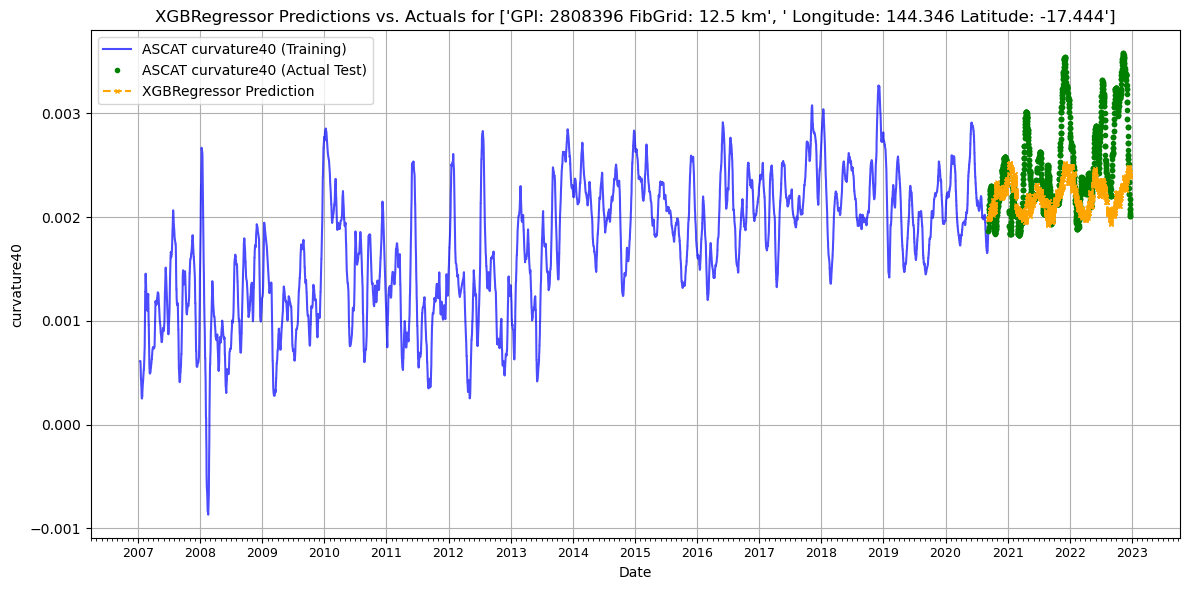

2026-03-16 22:30:58,439 - Starting expanding window forecast for 2059 points...
2026-03-16 22:31:14,348 - -- 5% done
2026-03-16 22:31:28,568 - -- 10% done
2026-03-16 22:31:44,424 - -- 15% done
2026-03-16 22:32:00,420 - -- 19% done
2026-03-16 22:32:16,099 - -- 24% done
2026-03-16 22:32:31,086 - -- 29% done
2026-03-16 22:32:47,055 - -- 34% done
2026-03-16 22:33:03,713 - -- 39% done
2026-03-16 22:33:20,319 - -- 44% done
2026-03-16 22:33:37,193 - -- 49% done
2026-03-16 22:33:54,027 - -- 53% done
2026-03-16 22:34:10,857 - -- 58% done
2026-03-16 22:34:27,805 - -- 63% done
2026-03-16 22:34:44,939 - -- 68% done
2026-03-16 22:35:02,246 - -- 73% done
2026-03-16 22:35:19,551 - -- 78% done
2026-03-16 22:35:37,030 - -- 83% done
2026-03-16 22:35:52,829 - -- 87% done
2026-03-16 22:36:10,714 - -- 92% done
2026-03-16 22:36:28,765 - -- 97% done
2026-03-16 22:36:39,587 - -- 100% done
2026-03-16 22:36:39,597 - Expanding window predictions saved to ./images/curvature_no_backscatter/lagged/Australia_2808396

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2808396/gpi_curvature40_expanding_window.png


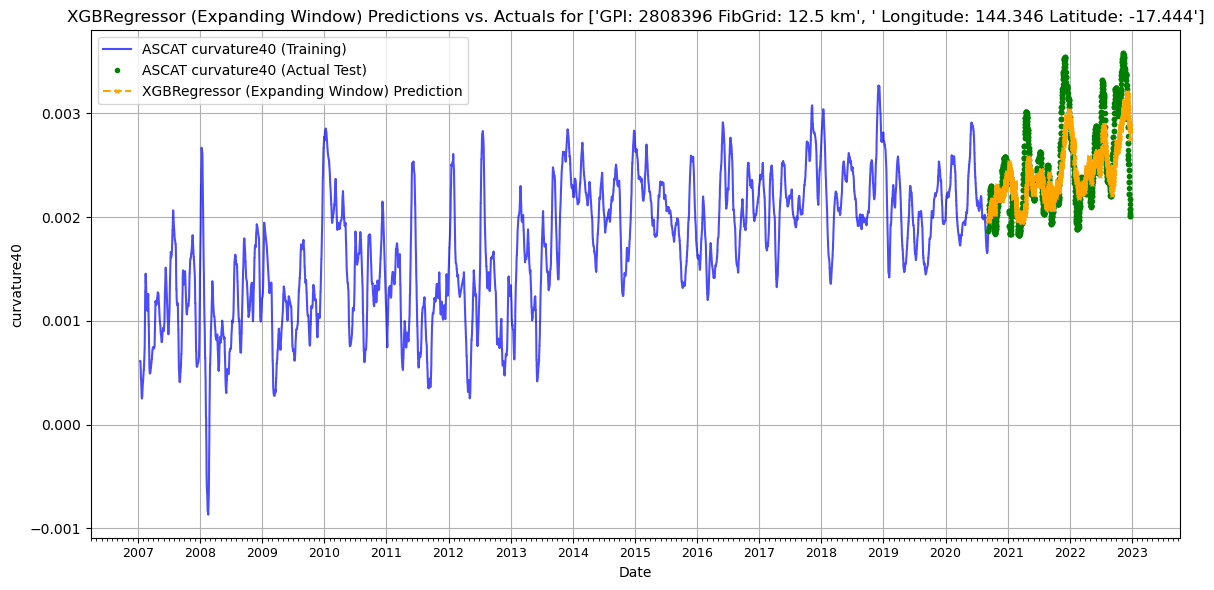

2026-03-16 22:36:40,411 - 
Final Performance:
2026-03-16 22:36:40,412 - RMSE: 0.00030 | MAE: 0.00023 | R2: 0.51987
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 22:36:45,263 - gpi: 2718799, lat: -20.75188446044922, lon: 147.48141479492188
2026-03-16 22:36:45,285 - Training data size: 8236
2026-03-16 22:36:45,285 - Testing data size: 2060
2026-03-16 22:36:45,289 - 
--- Baseline Model Performance ---
2026-03-16 22:36:45,296 - 
Climatology Model (Monthly Average):
2026-03-16 22:36:45,296 -   RMSE: 0.00066
2026-03-16 22:36:45,297 -   MAE: 0.00058
2026-03-16 22:36:45,298 -   R2: -2.78886
2026-03-16 22:36:45,298 -   Temporal Correlation: 0.15589
2026-03-16 22:36:45,300 - 
Random Noise Baseline:
2026-03-16 22:36:45,301 -   RMSE: 0.00048
2026-03-16 22:36:45,301 -   MAE: 0.00039
2026-03-16 2

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2718799/gpi_curvature40.png


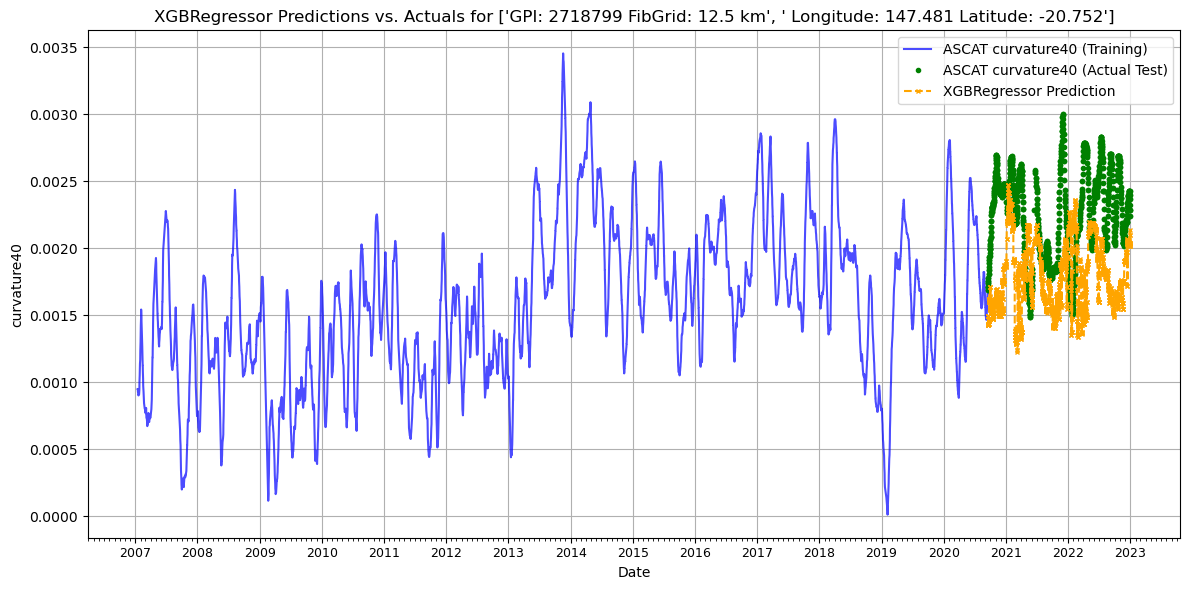

2026-03-16 22:40:27,029 - Starting expanding window forecast for 2060 points...
2026-03-16 22:40:42,763 - -- 5% done
2026-03-16 22:40:58,443 - -- 10% done
2026-03-16 22:41:13,883 - -- 15% done
2026-03-16 22:41:29,330 - -- 19% done
2026-03-16 22:41:45,421 - -- 24% done
2026-03-16 22:42:01,525 - -- 29% done
2026-03-16 22:42:17,899 - -- 34% done
2026-03-16 22:42:34,286 - -- 39% done
2026-03-16 22:42:51,109 - -- 44% done
2026-03-16 22:43:07,877 - -- 49% done
2026-03-16 22:43:24,701 - -- 53% done
2026-03-16 22:43:41,605 - -- 58% done
2026-03-16 22:43:57,105 - -- 63% done
2026-03-16 22:44:14,273 - -- 68% done
2026-03-16 22:44:31,744 - -- 73% done
2026-03-16 22:44:49,151 - -- 78% done
2026-03-16 22:45:06,836 - -- 83% done
2026-03-16 22:45:24,630 - -- 87% done
2026-03-16 22:45:42,203 - -- 92% done
2026-03-16 22:45:59,783 - -- 97% done
2026-03-16 22:46:10,479 - -- 100% done
2026-03-16 22:46:10,492 - Expanding window predictions saved to ./images/curvature_no_backscatter/lagged/Australia_2718799

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2718799/gpi_curvature40_expanding_window.png


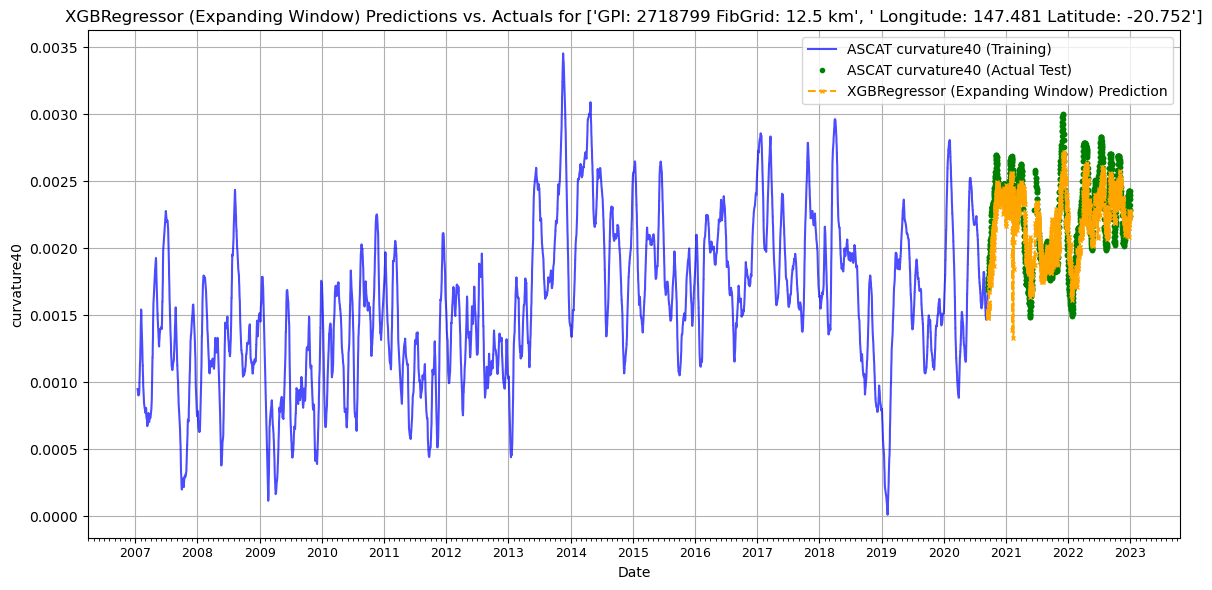

2026-03-16 22:46:11,188 - 
Final Performance:
2026-03-16 22:46:11,189 - RMSE: 0.00020 | MAE: 0.00016 | R2: 0.65776
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 22:46:15,009 - gpi: 2606988, lat: -24.98216438293457, lon: 148.08761596679688
2026-03-16 22:46:15,028 - Training data size: 8601
2026-03-16 22:46:15,029 - Testing data size: 2151
2026-03-16 22:46:15,033 - 
--- Baseline Model Performance ---
2026-03-16 22:46:15,039 - 
Climatology Model (Monthly Average):
2026-03-16 22:46:15,039 -   RMSE: 0.00044
2026-03-16 22:46:15,040 -   MAE: 0.00036
2026-03-16 22:46:15,040 -   R2: 0.03237
2026-03-16 22:46:15,041 -   Temporal Correlation: 0.56668
2026-03-16 22:46:15,042 - 
Random Noise Baseline:
2026-03-16 22:46:15,043 -   RMSE: 0.00063
2026-03-16 22:46:15,043 -   MAE: 0.00050
2026-03-16 22

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2606988/gpi_curvature40.png


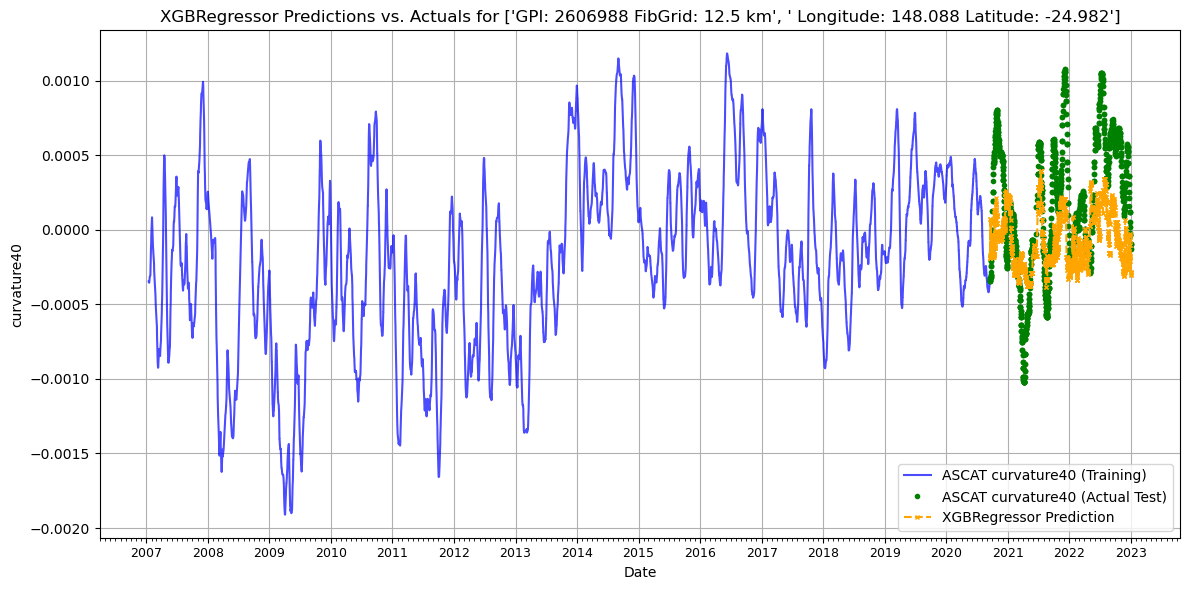

2026-03-16 22:49:56,410 - Starting expanding window forecast for 2151 points...
2026-03-16 22:50:01,282 - -- 5% done
2026-03-16 22:50:06,184 - -- 9% done
2026-03-16 22:50:11,045 - -- 14% done
2026-03-16 22:50:15,366 - -- 19% done
2026-03-16 22:50:20,101 - -- 23% done
2026-03-16 22:50:25,019 - -- 28% done
2026-03-16 22:50:29,937 - -- 33% done
2026-03-16 22:50:34,925 - -- 37% done
2026-03-16 22:50:39,896 - -- 42% done
2026-03-16 22:50:44,880 - -- 46% done
2026-03-16 22:50:49,876 - -- 51% done
2026-03-16 22:50:54,926 - -- 56% done
2026-03-16 22:50:59,930 - -- 60% done
2026-03-16 22:51:04,965 - -- 65% done
2026-03-16 22:51:10,019 - -- 70% done
2026-03-16 22:51:15,029 - -- 74% done
2026-03-16 22:51:20,055 - -- 79% done
2026-03-16 22:51:24,898 - -- 84% done
2026-03-16 22:51:29,938 - -- 88% done
2026-03-16 22:51:35,040 - -- 93% done
2026-03-16 22:51:40,155 - -- 98% done
2026-03-16 22:51:42,886 - -- 100% done
2026-03-16 22:51:42,896 - Expanding window predictions saved to ./images/curvature_no

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2606988/gpi_curvature40_expanding_window.png


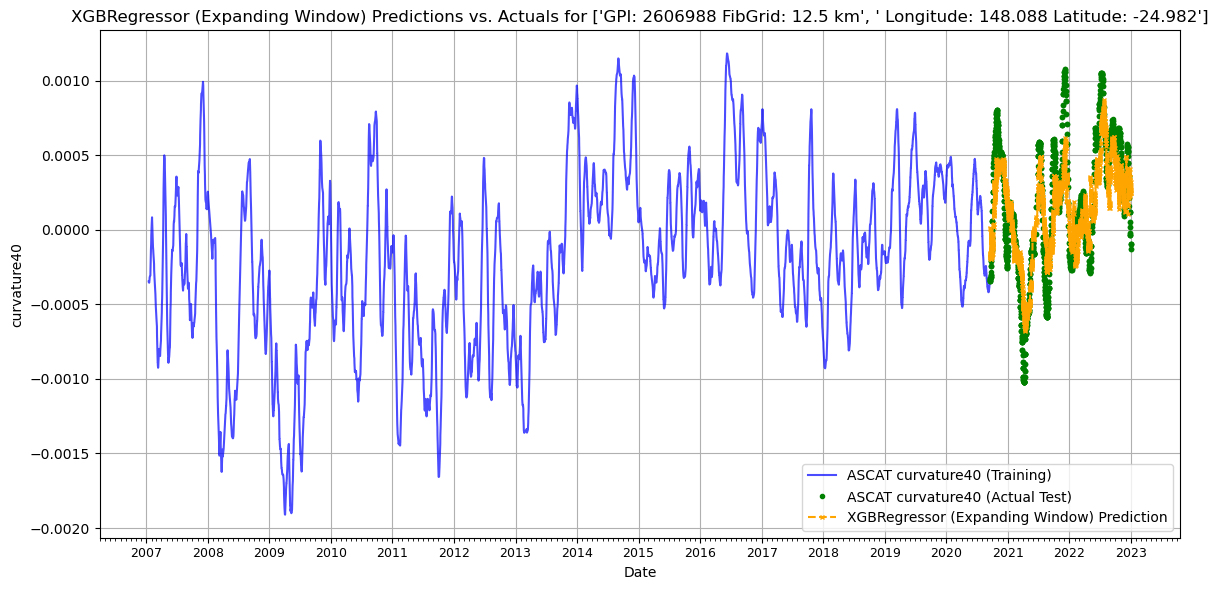

2026-03-16 22:51:43,622 - 
Final Performance:
2026-03-16 22:51:43,622 - RMSE: 0.00024 | MAE: 0.00020 | R2: 0.69955
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 22:51:47,598 - gpi: 2618866, lat: -24.526512145996094, lon: 150.86622619628906
2026-03-16 22:51:47,611 - Training data size: 8644
2026-03-16 22:51:47,611 - Testing data size: 2161
2026-03-16 22:51:47,615 - 
--- Baseline Model Performance ---
2026-03-16 22:51:47,622 - 
Climatology Model (Monthly Average):
2026-03-16 22:51:47,622 -   RMSE: 0.00052
2026-03-16 22:51:47,622 -   MAE: 0.00042
2026-03-16 22:51:47,623 -   R2: -0.63872
2026-03-16 22:51:47,623 -   Temporal Correlation: 0.58880
2026-03-16 22:51:47,625 - 
Random Noise Baseline:
2026-03-16 22:51:47,626 -   RMSE: 0.00056
2026-03-16 22:51:47,626 -   MAE: 0.00045
2026-03-16 

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2618866/gpi_curvature40.png


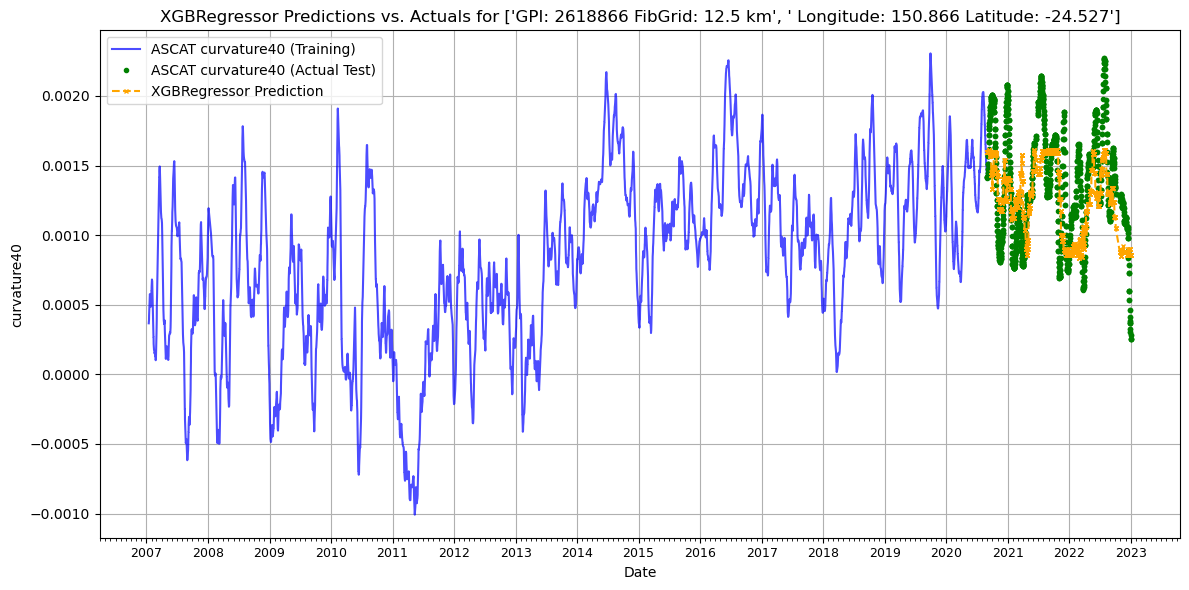

2026-03-16 22:55:23,329 - Starting expanding window forecast for 2161 points...
2026-03-16 22:55:33,933 - -- 5% done
2026-03-16 22:55:44,498 - -- 9% done
2026-03-16 22:55:55,303 - -- 14% done
2026-03-16 22:56:06,088 - -- 19% done
2026-03-16 22:56:16,808 - -- 23% done
2026-03-16 22:56:27,554 - -- 28% done
2026-03-16 22:56:38,501 - -- 32% done
2026-03-16 22:56:49,698 - -- 37% done
2026-03-16 22:57:00,695 - -- 42% done
2026-03-16 22:57:11,909 - -- 46% done
2026-03-16 22:57:23,035 - -- 51% done
2026-03-16 22:57:34,229 - -- 56% done
2026-03-16 22:57:45,439 - -- 60% done
2026-03-16 22:57:56,637 - -- 65% done
2026-03-16 22:58:07,866 - -- 69% done
2026-03-16 22:58:18,415 - -- 74% done
2026-03-16 22:58:28,743 - -- 79% done
2026-03-16 22:58:39,079 - -- 83% done
2026-03-16 22:58:49,413 - -- 88% done
2026-03-16 22:58:59,626 - -- 93% done
2026-03-16 22:59:09,931 - -- 97% done
2026-03-16 22:59:16,354 - -- 100% done
2026-03-16 22:59:16,365 - Expanding window predictions saved to ./images/curvature_no

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2618866/gpi_curvature40_expanding_window.png


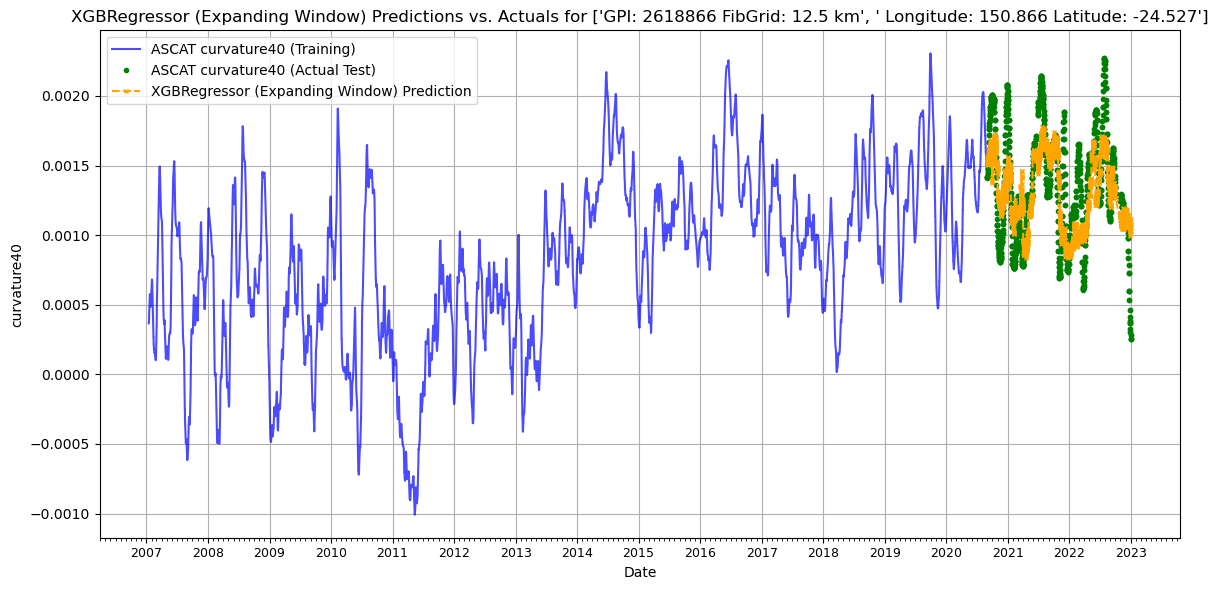

2026-03-16 22:59:17,069 - 
Final Performance:
2026-03-16 22:59:17,069 - RMSE: 0.00030 | MAE: 0.00024 | R2: 0.43773
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 22:59:21,633 - gpi: 2515328, lat: -28.55712127685547, lon: 149.7404327392578
2026-03-16 22:59:21,656 - Training data size: 8872
2026-03-16 22:59:21,657 - Testing data size: 2218
2026-03-16 22:59:21,660 - 
--- Baseline Model Performance ---
2026-03-16 22:59:21,667 - 
Climatology Model (Monthly Average):
2026-03-16 22:59:21,668 -   RMSE: 0.00137
2026-03-16 22:59:21,668 -   MAE: 0.00109
2026-03-16 22:59:21,668 -   R2: -0.83330
2026-03-16 22:59:21,669 -   Temporal Correlation: 0.49941
2026-03-16 22:59:21,670 - 
Random Noise Baseline:
2026-03-16 22:59:21,671 -   RMSE: 0.00144
2026-03-16 22:59:21,671 -   MAE: 0.00115
2026-03-16 22

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2515328/gpi_curvature40.png


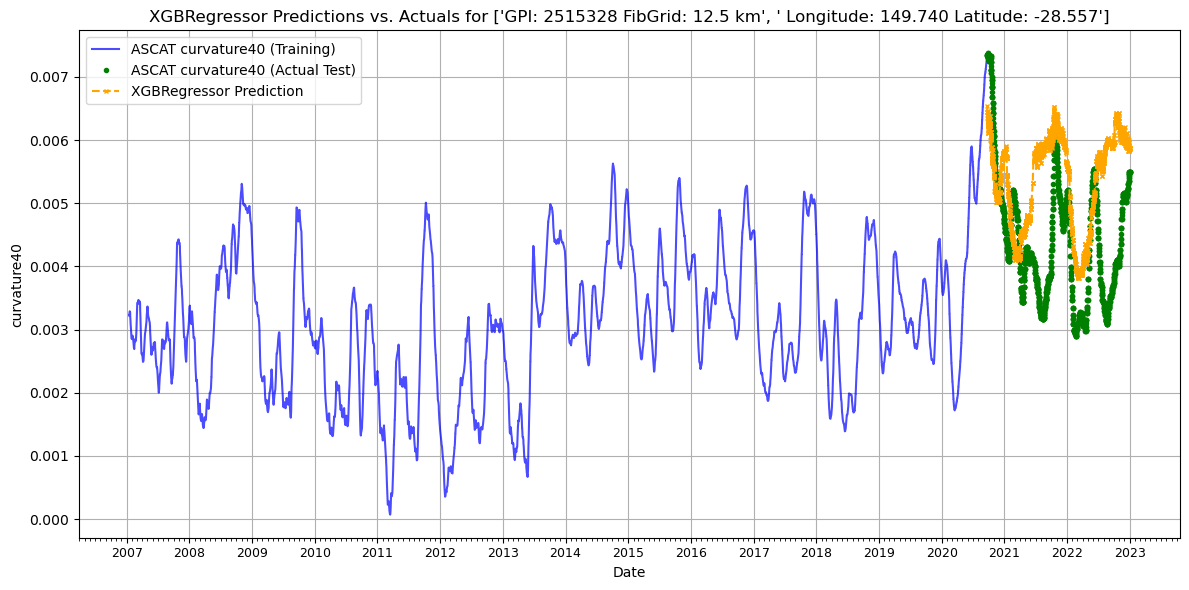

2026-03-16 23:03:31,326 - Starting expanding window forecast for 2218 points...
2026-03-16 23:03:43,048 - -- 5% done
2026-03-16 23:03:56,344 - -- 9% done
2026-03-16 23:04:09,826 - -- 14% done
2026-03-16 23:04:23,477 - -- 18% done
2026-03-16 23:04:37,054 - -- 23% done
2026-03-16 23:04:50,734 - -- 27% done
2026-03-16 23:05:04,422 - -- 32% done
2026-03-16 23:05:18,309 - -- 36% done
2026-03-16 23:05:32,284 - -- 41% done
2026-03-16 23:05:46,703 - -- 45% done
2026-03-16 23:06:00,752 - -- 50% done
2026-03-16 23:06:14,892 - -- 54% done
2026-03-16 23:06:28,969 - -- 59% done
2026-03-16 23:06:43,034 - -- 63% done
2026-03-16 23:06:57,141 - -- 68% done
2026-03-16 23:07:11,495 - -- 72% done
2026-03-16 23:07:24,365 - -- 77% done
2026-03-16 23:07:38,642 - -- 81% done
2026-03-16 23:07:53,257 - -- 86% done
2026-03-16 23:08:07,862 - -- 90% done
2026-03-16 23:08:22,587 - -- 95% done
2026-03-16 23:08:36,117 - -- 99% done
2026-03-16 23:08:38,924 - -- 100% done
2026-03-16 23:08:38,935 - Expanding window pred

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2515328/gpi_curvature40_expanding_window.png


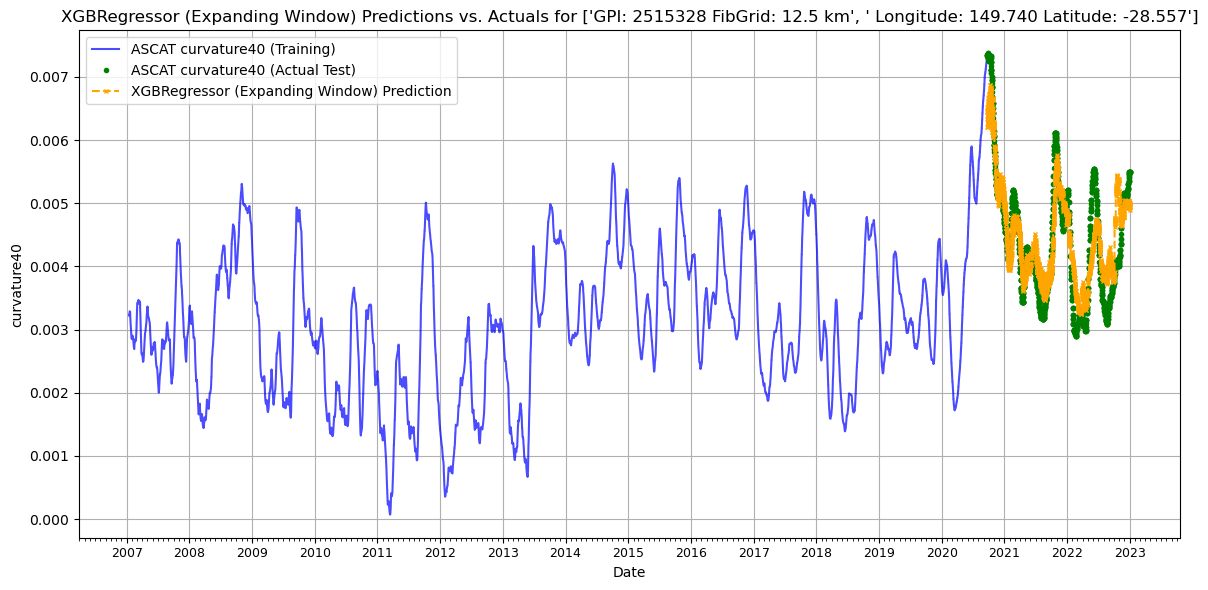

2026-03-16 23:08:39,639 - 
Final Performance:
2026-03-16 23:08:39,640 - RMSE: 0.00046 | MAE: 0.00037 | R2: 0.78973
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 23:08:43,718 - gpi: 2395765, lat: -33.40806579589844, lon: 150.53355407714844
2026-03-16 23:08:43,731 - Training data size: 9404
2026-03-16 23:08:43,732 - Testing data size: 2351
2026-03-16 23:08:43,735 - 
--- Baseline Model Performance ---
2026-03-16 23:08:43,742 - 
Climatology Model (Monthly Average):
2026-03-16 23:08:43,743 -   RMSE: 0.00114
2026-03-16 23:08:43,743 -   MAE: 0.00109
2026-03-16 23:08:43,744 -   R2: -10.88185
2026-03-16 23:08:43,744 -   Temporal Correlation: 0.20145
2026-03-16 23:08:43,746 - 
Random Noise Baseline:
2026-03-16 23:08:43,746 -   RMSE: 0.00047
2026-03-16 23:08:43,747 -   MAE: 0.00038
2026-03-16 

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2395765/gpi_curvature40.png


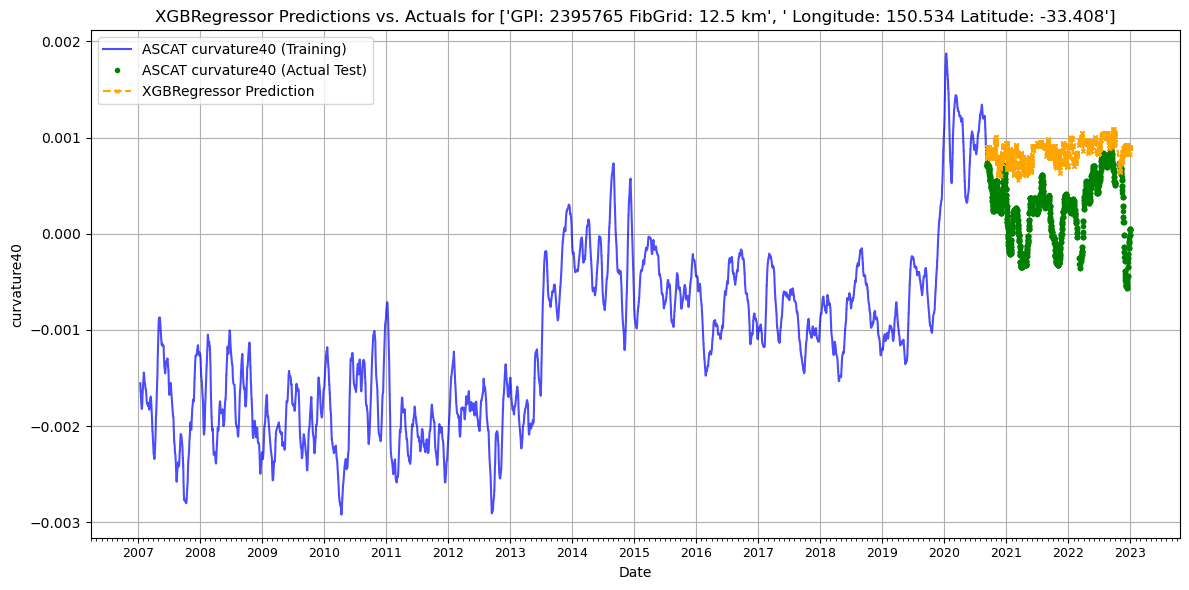

2026-03-16 23:12:09,183 - Starting expanding window forecast for 2351 points...
2026-03-16 23:12:18,998 - -- 4% done
2026-03-16 23:12:28,898 - -- 9% done
2026-03-16 23:12:38,794 - -- 13% done
2026-03-16 23:12:48,764 - -- 17% done
2026-03-16 23:12:58,695 - -- 21% done
2026-03-16 23:13:08,696 - -- 26% done
2026-03-16 23:13:18,773 - -- 30% done
2026-03-16 23:13:28,907 - -- 34% done
2026-03-16 23:13:38,242 - -- 38% done
2026-03-16 23:13:47,863 - -- 43% done
2026-03-16 23:13:58,223 - -- 47% done
2026-03-16 23:14:08,643 - -- 51% done
2026-03-16 23:14:19,170 - -- 55% done
2026-03-16 23:14:29,614 - -- 60% done
2026-03-16 23:14:40,042 - -- 64% done
2026-03-16 23:14:50,650 - -- 68% done
2026-03-16 23:15:01,345 - -- 72% done
2026-03-16 23:15:12,047 - -- 77% done
2026-03-16 23:15:22,839 - -- 81% done
2026-03-16 23:15:33,602 - -- 85% done
2026-03-16 23:15:44,426 - -- 89% done
2026-03-16 23:15:55,181 - -- 94% done
2026-03-16 23:16:06,090 - -- 98% done
2026-03-16 23:16:11,829 - -- 100% done
2026-03-1

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2395765/gpi_curvature40_expanding_window.png


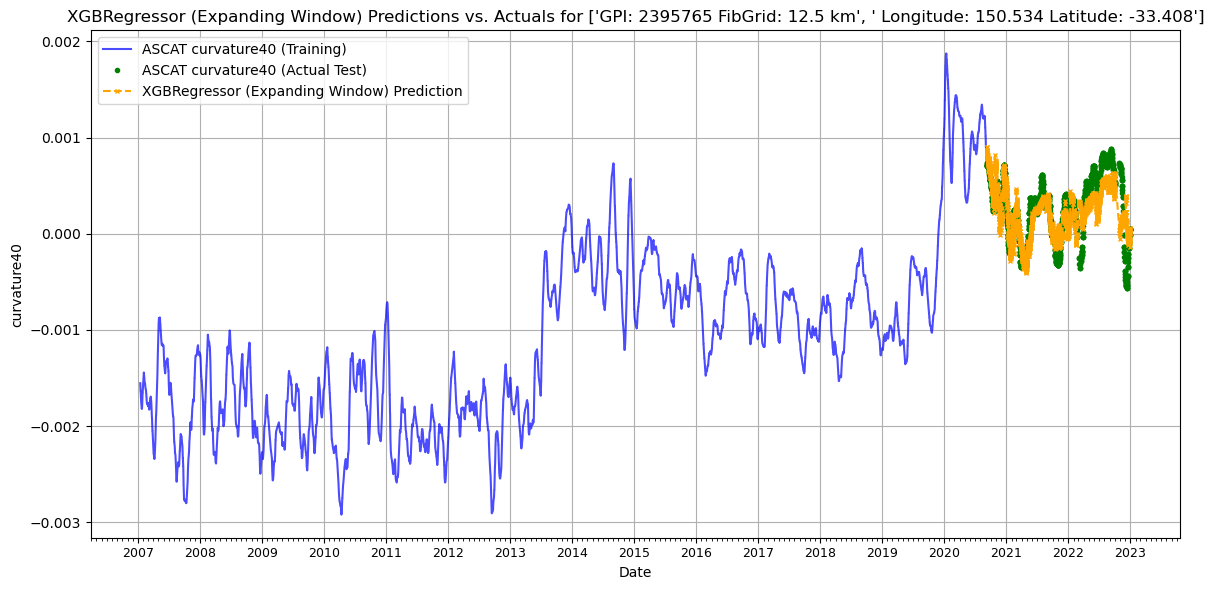

2026-03-16 23:16:12,541 - 
Final Performance:
2026-03-16 23:16:12,541 - RMSE: 0.00021 | MAE: 0.00016 | R2: 0.59728
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 23:16:16,702 - gpi: 2303173, lat: -37.35226058959961, lon: 149.42247009277344
2026-03-16 23:16:16,717 - Training data size: 9843
2026-03-16 23:16:16,717 - Testing data size: 2461
2026-03-16 23:16:16,721 - 
--- Baseline Model Performance ---
2026-03-16 23:16:16,728 - 
Climatology Model (Monthly Average):
2026-03-16 23:16:16,728 -   RMSE: 0.00139
2026-03-16 23:16:16,729 -   MAE: 0.00127
2026-03-16 23:16:16,729 -   R2: -5.39330
2026-03-16 23:16:16,730 -   Temporal Correlation: 0.23200
2026-03-16 23:16:16,731 - 
Random Noise Baseline:
2026-03-16 23:16:16,732 -   RMSE: 0.00076
2026-03-16 23:16:16,732 -   MAE: 0.00062
2026-03-16 2

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2303173/gpi_curvature40.png


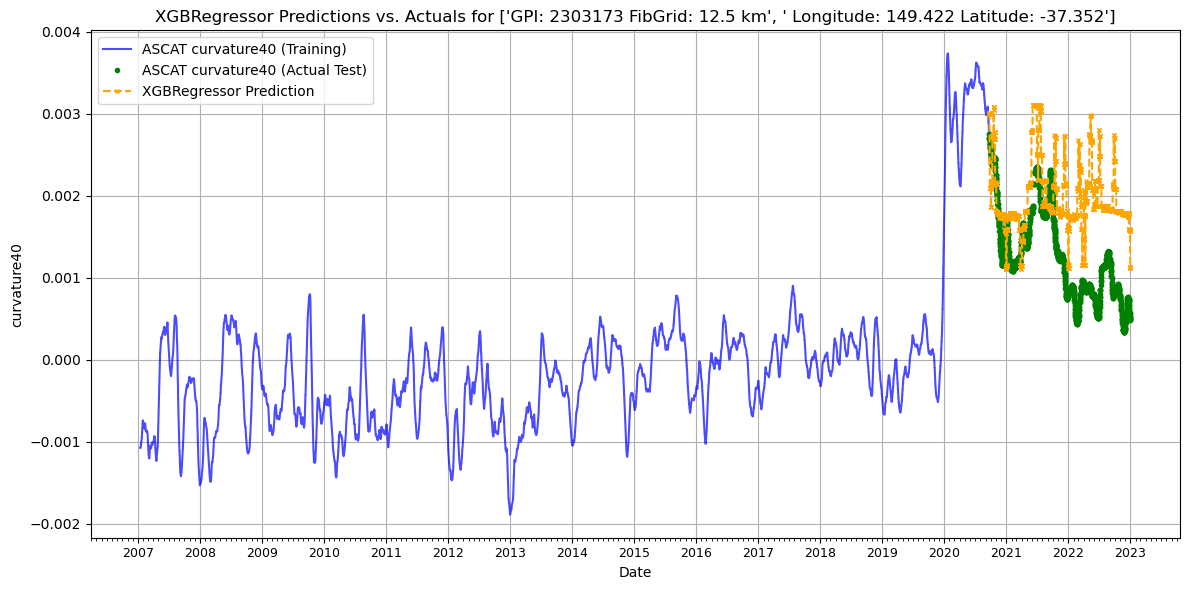

2026-03-16 23:19:53,695 - Starting expanding window forecast for 2461 points...
2026-03-16 23:20:04,223 - -- 4% done
2026-03-16 23:20:14,881 - -- 8% done
2026-03-16 23:20:25,456 - -- 12% done
2026-03-16 23:20:36,032 - -- 16% done
2026-03-16 23:20:46,827 - -- 20% done
2026-03-16 23:20:56,879 - -- 24% done
2026-03-16 23:21:07,543 - -- 28% done
2026-03-16 23:21:18,532 - -- 33% done
2026-03-16 23:21:29,456 - -- 37% done
2026-03-16 23:21:40,500 - -- 41% done
2026-03-16 23:21:51,519 - -- 45% done
2026-03-16 23:22:02,724 - -- 49% done
2026-03-16 23:22:13,920 - -- 53% done
2026-03-16 23:22:25,098 - -- 57% done
2026-03-16 23:22:36,380 - -- 61% done
2026-03-16 23:22:47,676 - -- 65% done
2026-03-16 23:22:59,119 - -- 69% done
2026-03-16 23:23:10,521 - -- 73% done
2026-03-16 23:23:21,024 - -- 77% done
2026-03-16 23:23:31,405 - -- 81% done
2026-03-16 23:23:42,817 - -- 85% done
2026-03-16 23:23:54,428 - -- 89% done
2026-03-16 23:24:06,031 - -- 93% done
2026-03-16 23:24:17,627 - -- 98% done
2026-03-16

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2303173/gpi_curvature40_expanding_window.png


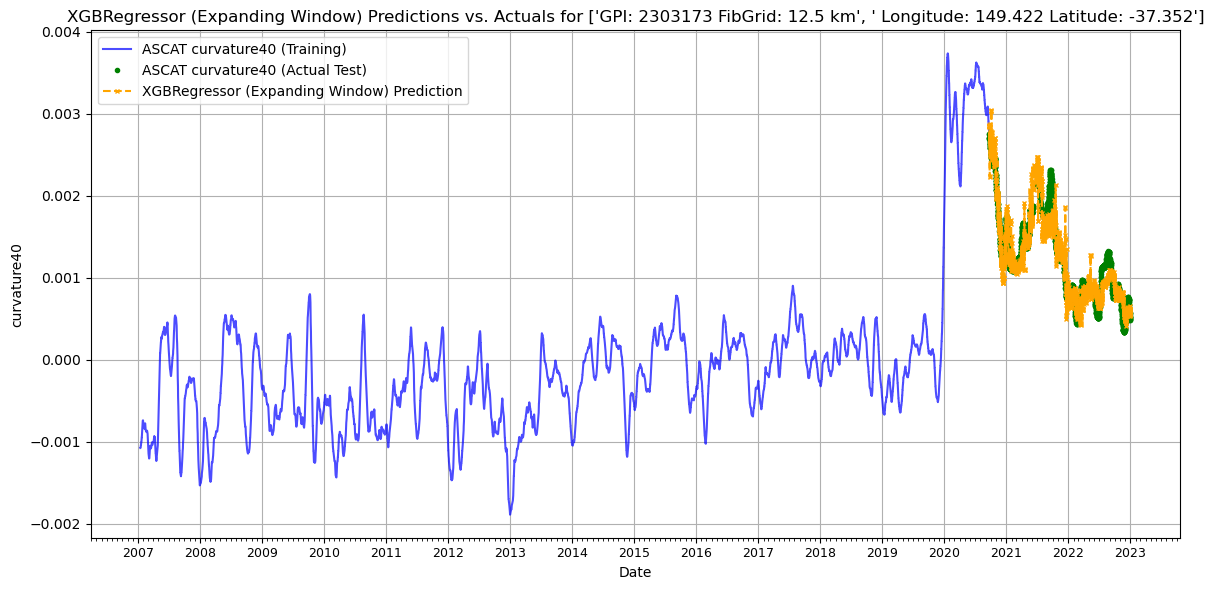

2026-03-16 23:24:25,578 - 
Final Performance:
2026-03-16 23:24:25,578 - RMSE: 0.00019 | MAE: 0.00015 | R2: 0.87701
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 23:24:29,900 - gpi: 2326162, lat: -36.3551139831543, lon: 143.43472290039062
2026-03-16 23:24:29,914 - Training data size: 10080
2026-03-16 23:24:29,914 - Testing data size: 2520
2026-03-16 23:24:29,918 - 
--- Baseline Model Performance ---
2026-03-16 23:24:29,926 - 
Climatology Model (Monthly Average):
2026-03-16 23:24:29,926 -   RMSE: 0.00112
2026-03-16 23:24:29,926 -   MAE: 0.00076
2026-03-16 23:24:29,927 -   R2: 0.20795
2026-03-16 23:24:29,927 -   Temporal Correlation: 0.48210
2026-03-16 23:24:29,929 - 
Random Noise Baseline:
2026-03-16 23:24:29,930 -   RMSE: 0.00176
2026-03-16 23:24:29,930 -   MAE: 0.00142
2026-03-16 23

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2326162/gpi_curvature40.png


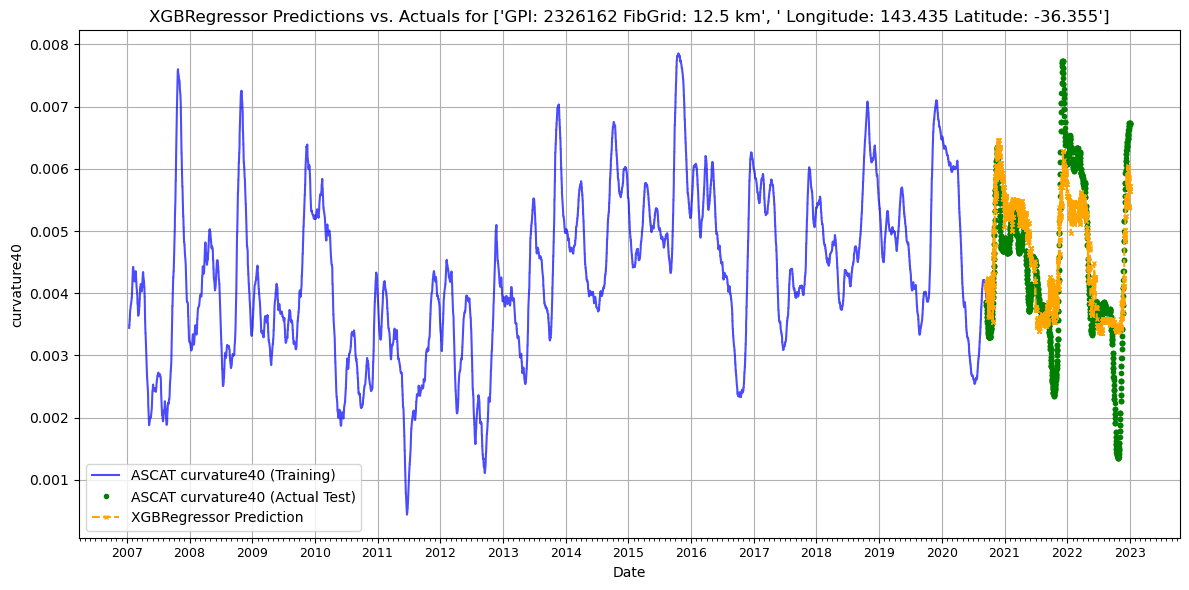

2026-03-16 23:28:03,038 - Starting expanding window forecast for 2520 points...
2026-03-16 23:28:13,149 - -- 4% done
2026-03-16 23:28:24,104 - -- 8% done
2026-03-16 23:28:35,145 - -- 12% done
2026-03-16 23:28:46,195 - -- 16% done
2026-03-16 23:28:57,317 - -- 20% done
2026-03-16 23:29:08,459 - -- 24% done
2026-03-16 23:29:19,859 - -- 28% done
2026-03-16 23:29:31,341 - -- 32% done
2026-03-16 23:29:41,695 - -- 36% done
2026-03-16 23:29:53,023 - -- 40% done
2026-03-16 23:30:04,755 - -- 44% done
2026-03-16 23:30:15,849 - -- 48% done
2026-03-16 23:30:27,146 - -- 52% done
2026-03-16 23:30:38,666 - -- 56% done
2026-03-16 23:30:50,196 - -- 60% done
2026-03-16 23:31:01,796 - -- 63% done
2026-03-16 23:31:13,477 - -- 67% done
2026-03-16 23:31:25,136 - -- 71% done
2026-03-16 23:31:36,785 - -- 75% done
2026-03-16 23:31:47,151 - -- 79% done
2026-03-16 23:31:57,456 - -- 83% done
2026-03-16 23:32:07,852 - -- 87% done
2026-03-16 23:32:19,889 - -- 91% done
2026-03-16 23:32:31,828 - -- 95% done
2026-03-16

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2326162/gpi_curvature40_expanding_window.png


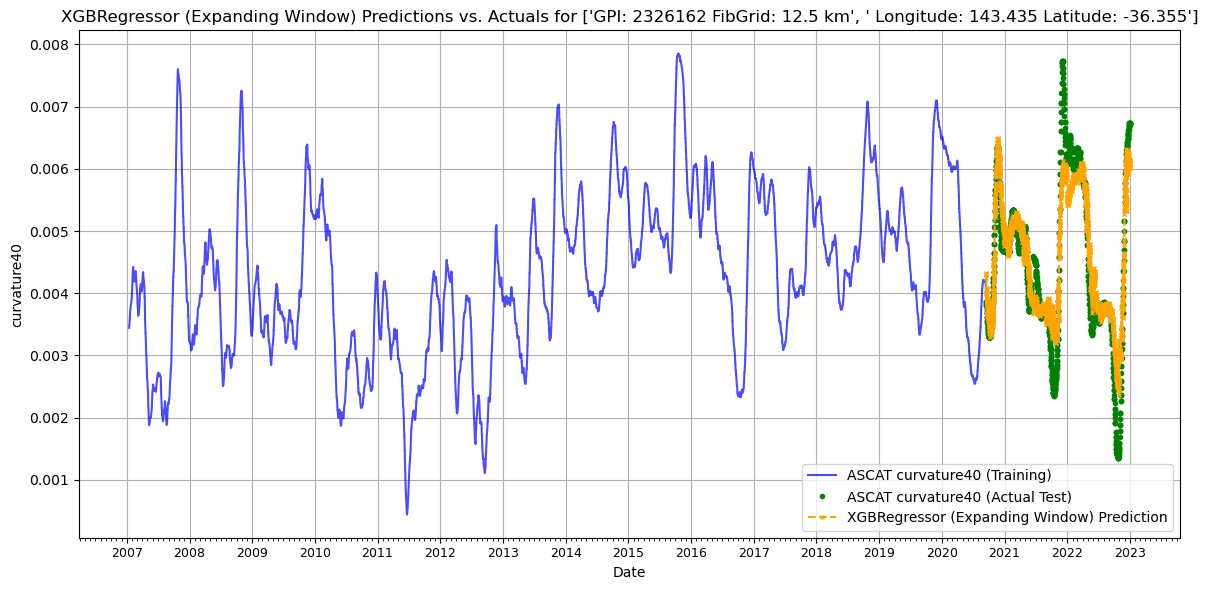

2026-03-16 23:32:47,203 - 
Final Performance:
2026-03-16 23:32:47,203 - RMSE: 0.00050 | MAE: 0.00037 | R2: 0.83925
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 23:32:51,773 - gpi: 2690836, lat: -21.798175811767578, lon: 117.08753967285156
2026-03-16 23:32:51,786 - Training data size: 8681
2026-03-16 23:32:51,787 - Testing data size: 2171
2026-03-16 23:32:51,790 - 
--- Baseline Model Performance ---
2026-03-16 23:32:51,797 - 
Climatology Model (Monthly Average):
2026-03-16 23:32:51,798 -   RMSE: 0.00043
2026-03-16 23:32:51,798 -   MAE: 0.00037
2026-03-16 23:32:51,798 -   R2: -0.81333
2026-03-16 23:32:51,799 -   Temporal Correlation: 0.50829
2026-03-16 23:32:51,801 - 
Random Noise Baseline:
2026-03-16 23:32:51,802 -   RMSE: 0.00046
2026-03-16 23:32:51,802 -   MAE: 0.00036
2026-03-16 

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2690836/gpi_curvature40.png


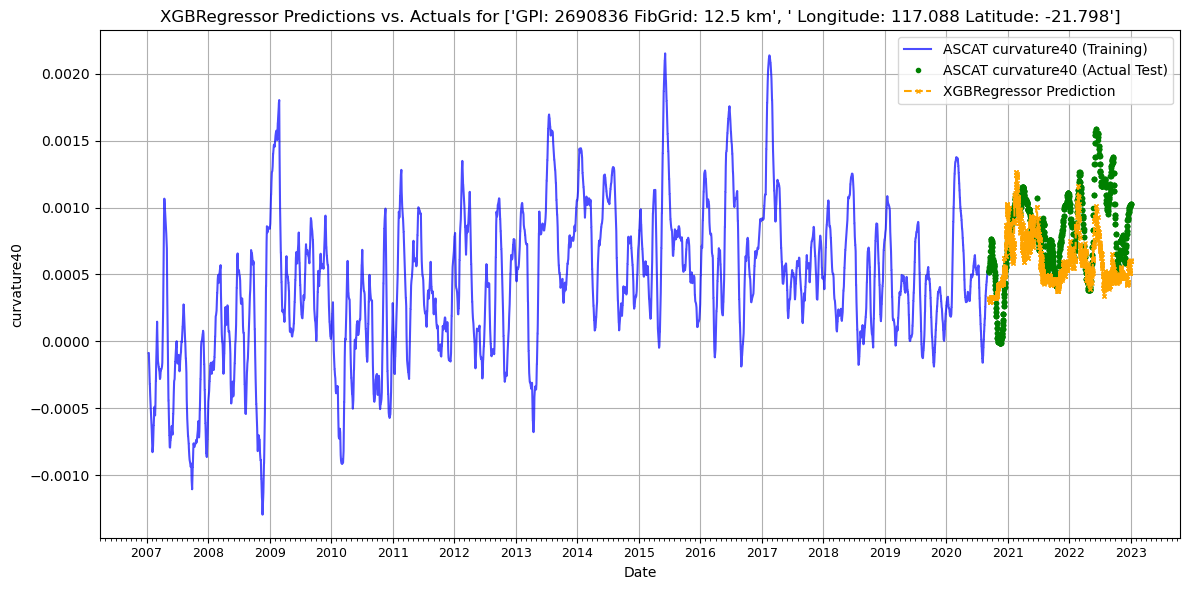

2026-03-16 23:36:30,069 - Starting expanding window forecast for 2171 points...
2026-03-16 23:36:48,758 - -- 5% done
2026-03-16 23:37:06,387 - -- 9% done
2026-03-16 23:37:22,902 - -- 14% done
2026-03-16 23:37:41,666 - -- 18% done
2026-03-16 23:38:00,647 - -- 23% done
2026-03-16 23:38:16,891 - -- 28% done
2026-03-16 23:38:33,695 - -- 32% done
2026-03-16 23:38:51,721 - -- 37% done
2026-03-16 23:39:08,538 - -- 41% done
2026-03-16 23:39:27,856 - -- 46% done
2026-03-16 23:39:47,331 - -- 51% done
2026-03-16 23:40:06,789 - -- 55% done
2026-03-16 23:40:26,256 - -- 60% done
2026-03-16 23:40:46,162 - -- 64% done
2026-03-16 23:41:05,851 - -- 69% done
2026-03-16 23:41:25,776 - -- 74% done
2026-03-16 23:41:45,501 - -- 78% done
2026-03-16 23:42:05,330 - -- 83% done
2026-03-16 23:42:24,751 - -- 88% done
2026-03-16 23:42:44,469 - -- 92% done
2026-03-16 23:43:04,615 - -- 97% done
2026-03-16 23:43:18,981 - -- 100% done
2026-03-16 23:43:18,992 - Expanding window predictions saved to ./images/curvature_no

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2690836/gpi_curvature40_expanding_window.png


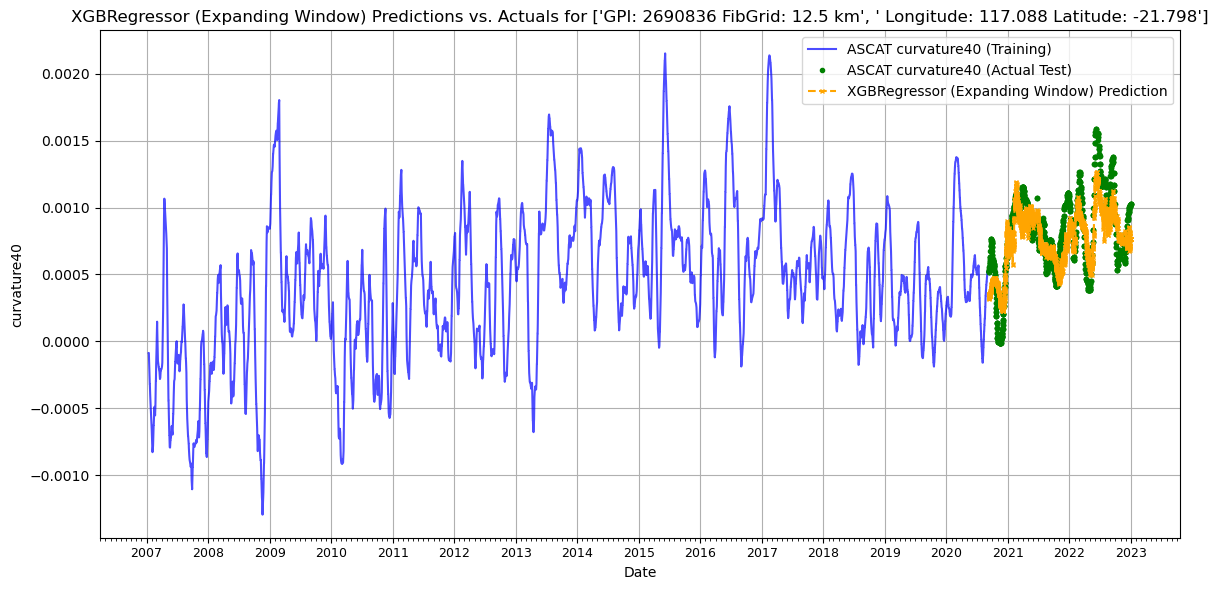

2026-03-16 23:43:19,806 - 
Final Performance:
2026-03-16 23:43:19,806 - RMSE: 0.00019 | MAE: 0.00016 | R2: 0.64757
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 23:43:24,408 - gpi: 2576119, lat: -26.174108505249023, lon: 115.25607299804688
2026-03-16 23:43:24,421 - Training data size: 8784
2026-03-16 23:43:24,422 - Testing data size: 2196
2026-03-16 23:43:24,426 - 
--- Baseline Model Performance ---
2026-03-16 23:43:24,434 - 
Climatology Model (Monthly Average):
2026-03-16 23:43:24,434 -   RMSE: 0.00041
2026-03-16 23:43:24,435 -   MAE: 0.00032
2026-03-16 23:43:24,435 -   R2: -0.29660
2026-03-16 23:43:24,435 -   Temporal Correlation: 0.16726
2026-03-16 23:43:24,437 - 
Random Noise Baseline:
2026-03-16 23:43:24,438 -   RMSE: 0.00051
2026-03-16 23:43:24,438 -   MAE: 0.00041
2026-03-16 

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2576119/gpi_curvature40.png


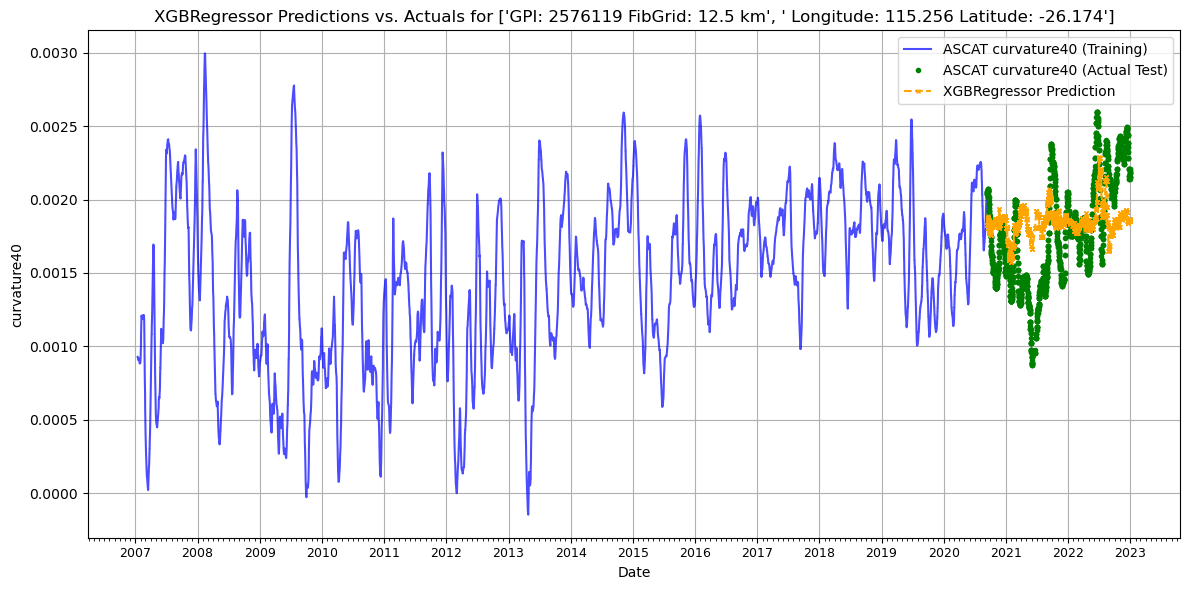

2026-03-16 23:46:53,600 - Starting expanding window forecast for 2196 points...
2026-03-16 23:46:58,977 - -- 5% done
2026-03-16 23:47:04,603 - -- 9% done
2026-03-16 23:47:10,764 - -- 14% done
2026-03-16 23:47:16,825 - -- 18% done
2026-03-16 23:47:22,898 - -- 23% done
2026-03-16 23:47:29,060 - -- 27% done
2026-03-16 23:47:35,246 - -- 32% done
2026-03-16 23:47:41,403 - -- 36% done
2026-03-16 23:47:46,845 - -- 41% done
2026-03-16 23:47:52,822 - -- 46% done
2026-03-16 23:47:59,006 - -- 50% done
2026-03-16 23:48:05,175 - -- 55% done
2026-03-16 23:48:11,355 - -- 59% done
2026-03-16 23:48:17,594 - -- 64% done
2026-03-16 23:48:23,815 - -- 68% done
2026-03-16 23:48:30,095 - -- 73% done
2026-03-16 23:48:36,375 - -- 77% done
2026-03-16 23:48:41,962 - -- 82% done
2026-03-16 23:48:48,124 - -- 87% done
2026-03-16 23:48:54,480 - -- 91% done
2026-03-16 23:49:00,874 - -- 96% done
2026-03-16 23:49:07,216 - -- 100% done
2026-03-16 23:49:07,227 - Expanding window predictions saved to ./images/curvature_no

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2576119/gpi_curvature40_expanding_window.png


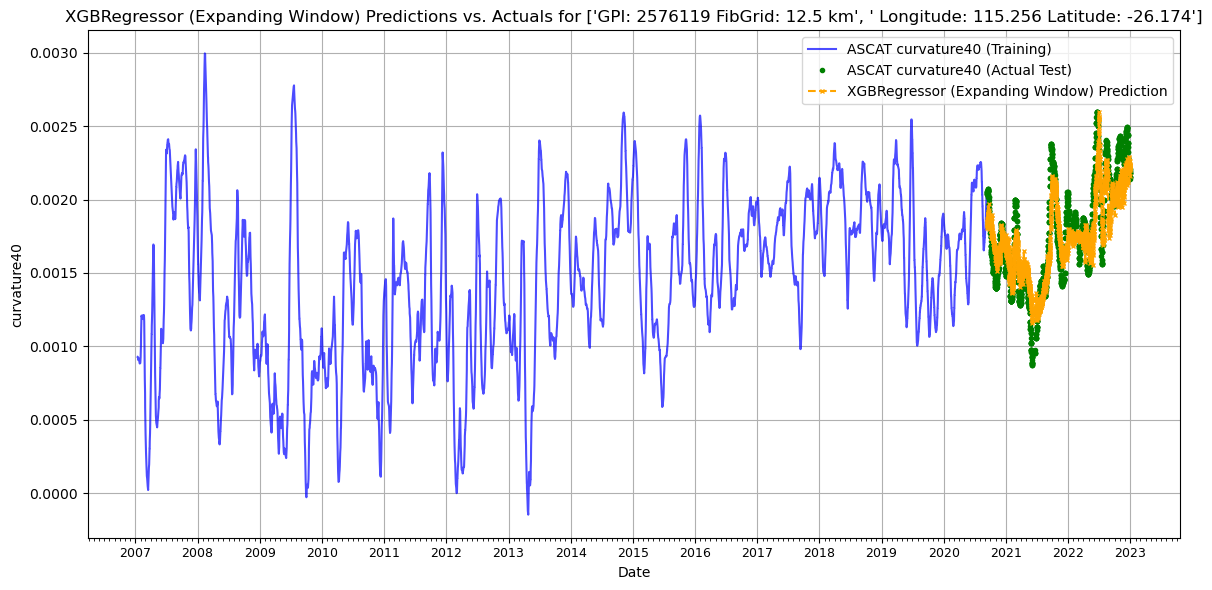

2026-03-16 23:49:07,927 - 
Final Performance:
2026-03-16 23:49:07,928 - RMSE: 0.00018 | MAE: 0.00015 | R2: 0.74095
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 23:49:12,603 - gpi: 2379934, lat: -34.06947708129883, lon: 115.94622802734375
2026-03-16 23:49:12,617 - Training data size: 9877
2026-03-16 23:49:12,617 - Testing data size: 2470
2026-03-16 23:49:12,621 - 
--- Baseline Model Performance ---
2026-03-16 23:49:12,629 - 
Climatology Model (Monthly Average):
2026-03-16 23:49:12,629 -   RMSE: 0.00050
2026-03-16 23:49:12,630 -   MAE: 0.00042
2026-03-16 23:49:12,630 -   R2: 0.30513
2026-03-16 23:49:12,630 -   Temporal Correlation: 0.59012
2026-03-16 23:49:12,633 - 
Random Noise Baseline:
2026-03-16 23:49:12,633 -   RMSE: 0.00084
2026-03-16 23:49:12,633 -   MAE: 0.00068
2026-03-16 23

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2379934/gpi_curvature40.png


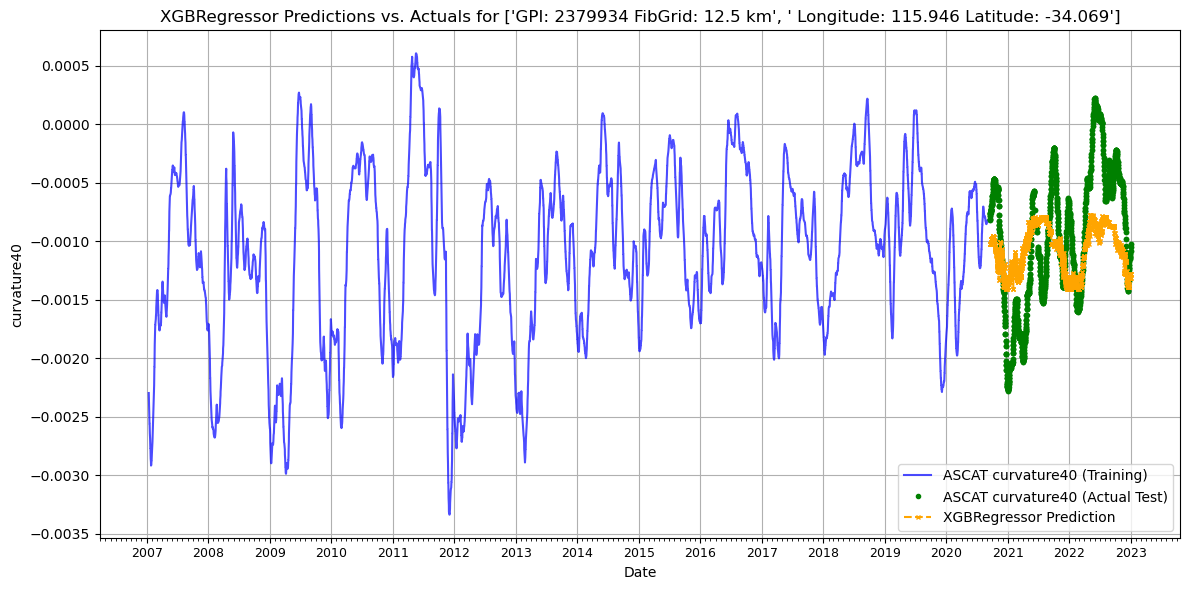

2026-03-16 23:52:56,381 - Starting expanding window forecast for 2470 points...
2026-03-16 23:53:01,029 - -- 4% done
2026-03-16 23:53:05,089 - -- 8% done
2026-03-16 23:53:09,190 - -- 12% done
2026-03-16 23:53:13,286 - -- 16% done
2026-03-16 23:53:17,433 - -- 20% done
2026-03-16 23:53:21,566 - -- 24% done
2026-03-16 23:53:26,115 - -- 28% done
2026-03-16 23:53:31,002 - -- 32% done
2026-03-16 23:53:35,918 - -- 36% done
2026-03-16 23:53:40,864 - -- 40% done
2026-03-16 23:53:45,861 - -- 45% done
2026-03-16 23:53:50,676 - -- 49% done
2026-03-16 23:53:55,688 - -- 53% done
2026-03-16 23:54:00,702 - -- 57% done
2026-03-16 23:54:05,726 - -- 61% done
2026-03-16 23:54:10,795 - -- 65% done
2026-03-16 23:54:15,905 - -- 69% done
2026-03-16 23:54:21,052 - -- 73% done
2026-03-16 23:54:26,219 - -- 77% done
2026-03-16 23:54:31,433 - -- 81% done
2026-03-16 23:54:36,598 - -- 85% done
2026-03-16 23:54:41,131 - -- 89% done
2026-03-16 23:54:46,204 - -- 93% done
2026-03-16 23:54:51,058 - -- 97% done
2026-03-16

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2379934/gpi_curvature40_expanding_window.png


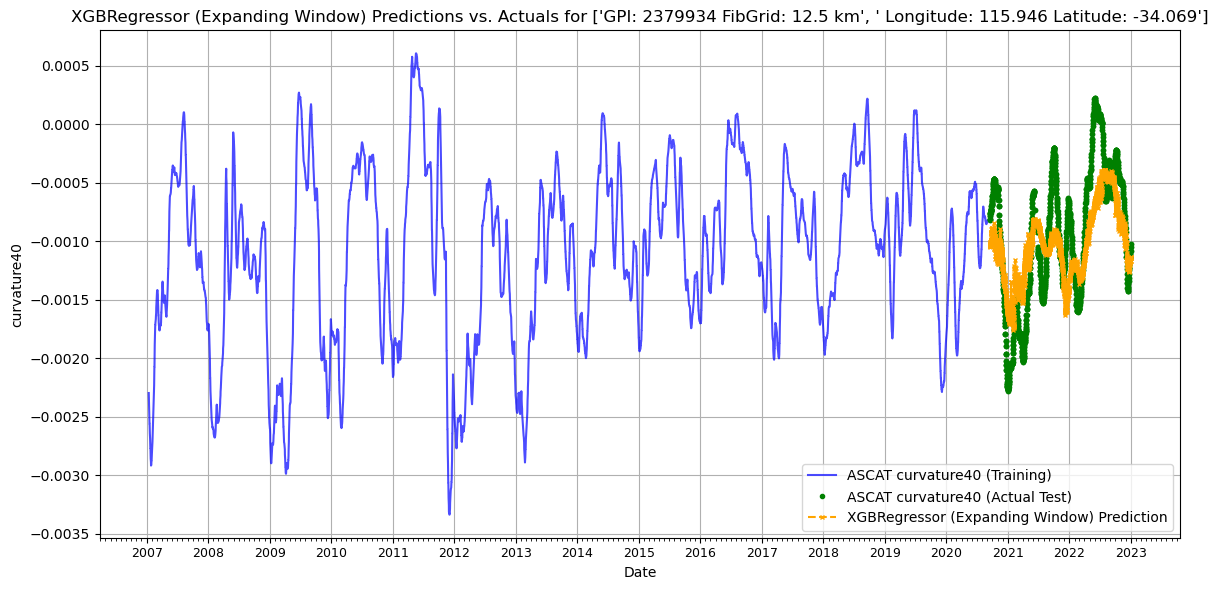

2026-03-16 23:54:55,115 - 
Final Performance:
2026-03-16 23:54:55,115 - RMSE: 0.00040 | MAE: 0.00034 | R2: 0.55614
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-16 23:54:59,539 - gpi: 2402792, lat: -33.116050720214844, lon: 123.47557067871094
2026-03-16 23:54:59,553 - Training data size: 9564
2026-03-16 23:54:59,553 - Testing data size: 2392
2026-03-16 23:54:59,557 - 
--- Baseline Model Performance ---
2026-03-16 23:54:59,564 - 
Climatology Model (Monthly Average):
2026-03-16 23:54:59,564 -   RMSE: 0.00223
2026-03-16 23:54:59,565 -   MAE: 0.00218
2026-03-16 23:54:59,565 -   R2: -25.36500
2026-03-16 23:54:59,565 -   Temporal Correlation: 0.23534
2026-03-16 23:54:59,568 - 
Random Noise Baseline:
2026-03-16 23:54:59,568 -   RMSE: 0.00061
2026-03-16 23:54:59,569 -   MAE: 0.00049
2026-03-16

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2402792/gpi_curvature40.png


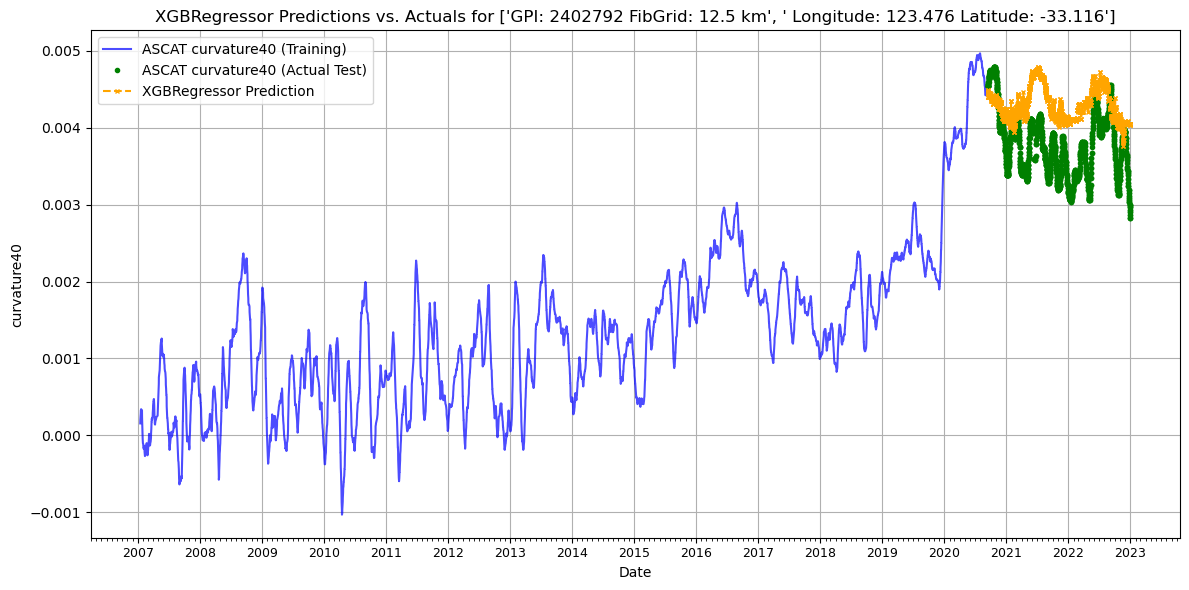

2026-03-16 23:58:30,532 - Starting expanding window forecast for 2392 points...
2026-03-16 23:58:45,320 - -- 4% done
2026-03-16 23:59:00,192 - -- 8% done
2026-03-16 23:59:15,168 - -- 13% done
2026-03-16 23:59:30,195 - -- 17% done
2026-03-16 23:59:45,264 - -- 21% done
2026-03-17 00:00:00,495 - -- 25% done
2026-03-17 00:00:15,761 - -- 29% done
2026-03-17 00:00:31,205 - -- 33% done
2026-03-17 00:00:46,655 - -- 38% done
2026-03-17 00:01:00,249 - -- 42% done
2026-03-17 00:01:13,756 - -- 46% done
2026-03-17 00:01:27,391 - -- 50% done
2026-03-17 00:01:41,068 - -- 54% done
2026-03-17 00:01:56,633 - -- 59% done
2026-03-17 00:02:10,573 - -- 63% done
2026-03-17 00:02:26,380 - -- 67% done
2026-03-17 00:02:42,500 - -- 71% done
2026-03-17 00:02:58,301 - -- 75% done
2026-03-17 00:03:12,416 - -- 79% done
2026-03-17 00:03:28,729 - -- 84% done
2026-03-17 00:03:42,815 - -- 88% done
2026-03-17 00:03:57,755 - -- 92% done
2026-03-17 00:04:14,134 - -- 96% done
2026-03-17 00:04:29,063 - -- 100% done
2026-03-1

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2402792/gpi_curvature40_expanding_window.png


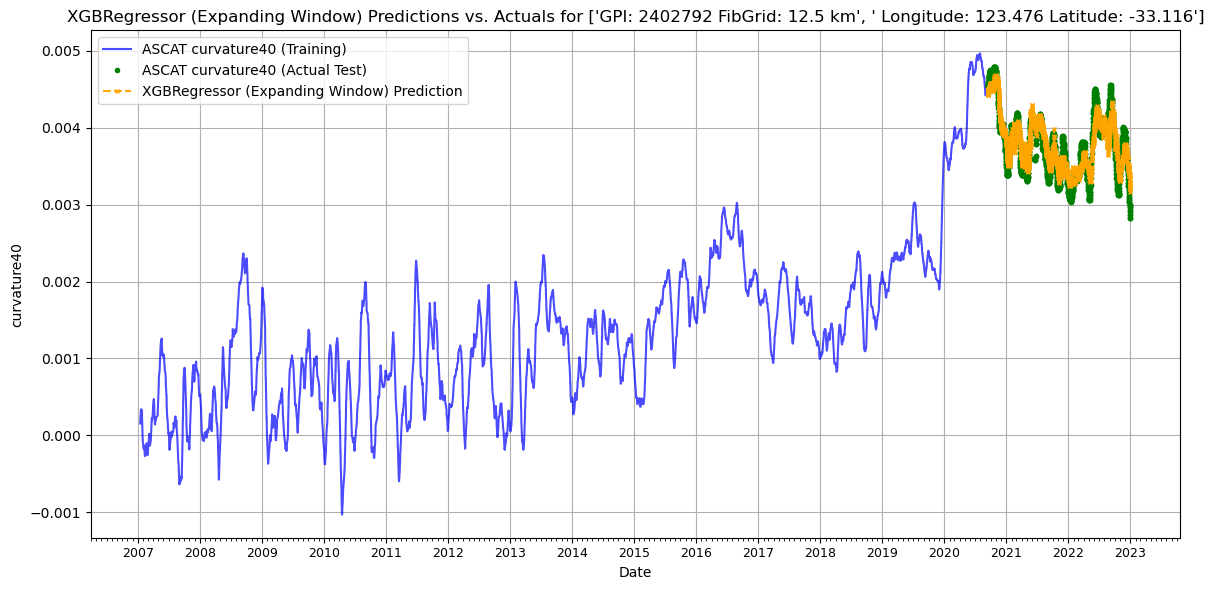

2026-03-17 00:04:29,763 - 
Final Performance:
2026-03-17 00:04:29,764 - RMSE: 0.00020 | MAE: 0.00017 | R2: 0.78604
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-17 00:04:33,925 - gpi: 2485019, lat: -29.76472282409668, lon: 152.56103515625
2026-03-17 00:04:33,938 - Training data size: 9243
2026-03-17 00:04:33,939 - Testing data size: 2311
2026-03-17 00:04:33,942 - 
--- Baseline Model Performance ---
2026-03-17 00:04:33,949 - 
Climatology Model (Monthly Average):
2026-03-17 00:04:33,950 -   RMSE: 0.00027
2026-03-17 00:04:33,950 -   MAE: 0.00021
2026-03-17 00:04:33,951 -   R2: -0.00343
2026-03-17 00:04:33,951 -   Temporal Correlation: 0.17826
2026-03-17 00:04:33,953 - 
Random Noise Baseline:
2026-03-17 00:04:33,953 -   RMSE: 0.00038
2026-03-17 00:04:33,954 -   MAE: 0.00030
2026-03-17 00:0

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2485019/gpi_curvature40.png


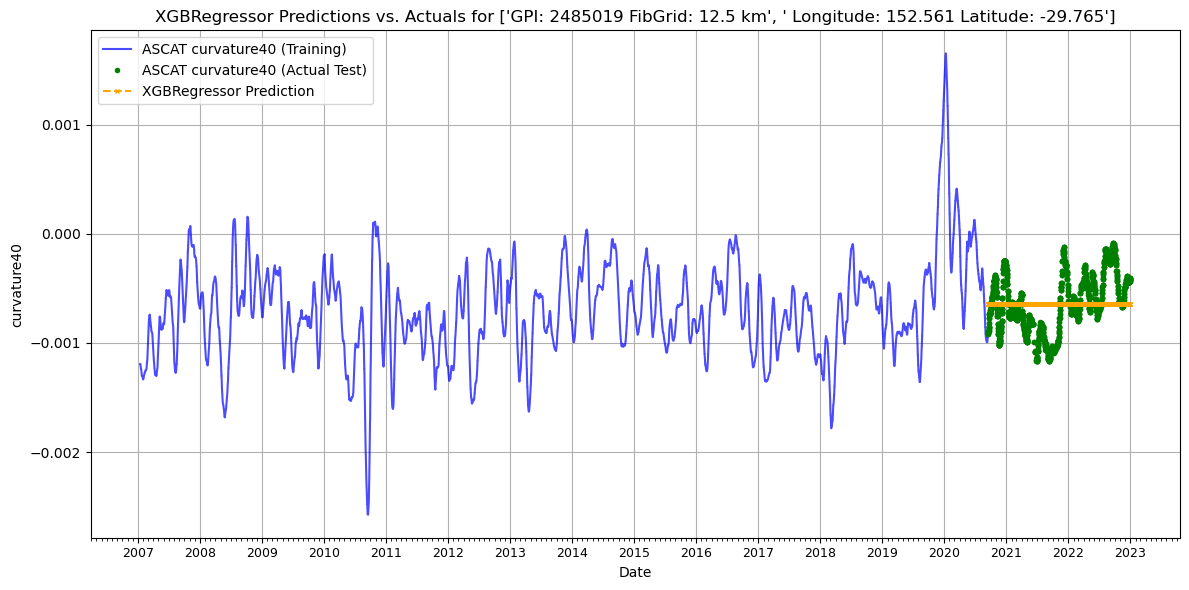

2026-03-17 00:07:41,310 - Starting expanding window forecast for 2311 points...
2026-03-17 00:07:51,775 - -- 4% done
2026-03-17 00:08:02,300 - -- 9% done
2026-03-17 00:08:12,898 - -- 13% done
2026-03-17 00:08:23,546 - -- 17% done
2026-03-17 00:08:34,170 - -- 22% done
2026-03-17 00:08:44,924 - -- 26% done
2026-03-17 00:08:54,801 - -- 30% done
2026-03-17 00:09:05,504 - -- 35% done
2026-03-17 00:09:16,378 - -- 39% done
2026-03-17 00:09:26,376 - -- 43% done
2026-03-17 00:09:37,441 - -- 48% done
2026-03-17 00:09:48,639 - -- 52% done
2026-03-17 00:09:58,741 - -- 56% done
2026-03-17 00:10:08,860 - -- 61% done
2026-03-17 00:10:19,598 - -- 65% done
2026-03-17 00:10:30,938 - -- 69% done
2026-03-17 00:10:42,295 - -- 74% done
2026-03-17 00:10:53,700 - -- 78% done
2026-03-17 00:11:05,159 - -- 82% done
2026-03-17 00:11:15,886 - -- 87% done
2026-03-17 00:11:27,197 - -- 91% done
2026-03-17 00:11:38,758 - -- 95% done
2026-03-17 00:11:50,327 - -- 100% done
2026-03-17 00:11:51,641 - -- 100% done
2026-03-

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2485019/gpi_curvature40_expanding_window.png


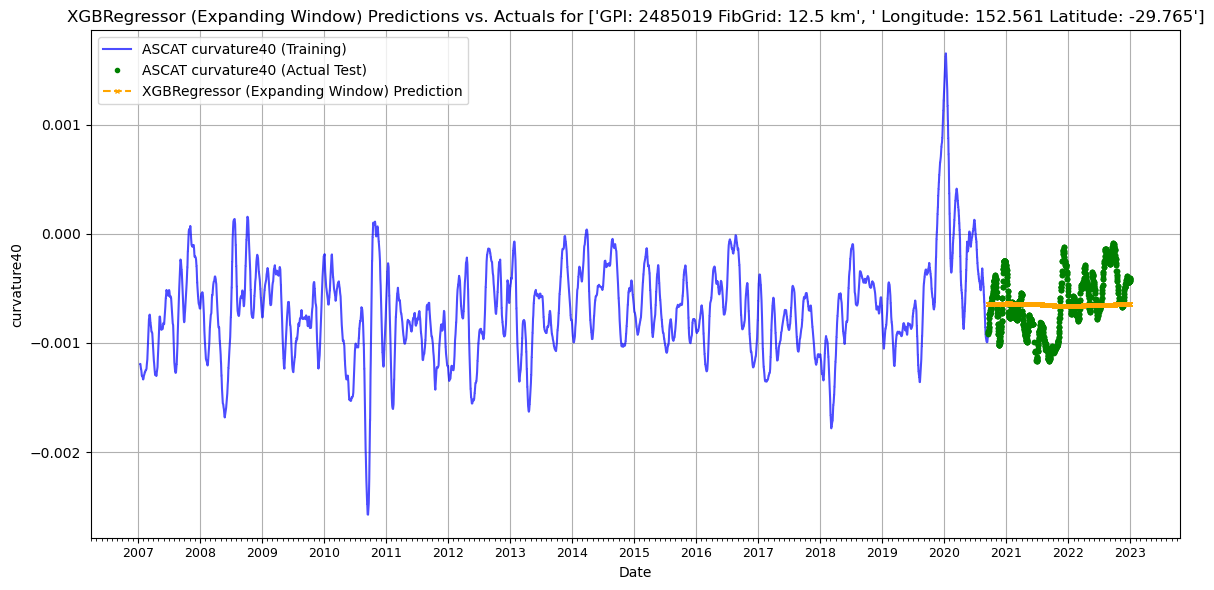

2026-03-17 00:11:52,357 - 
Final Performance:
2026-03-17 00:11:52,357 - RMSE: 0.00027 | MAE: 0.00022 | R2: -0.00737
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-17 00:11:56,729 - gpi: 2425315, lat: -32.18633270263672, lon: 116.10587310791016
2026-03-17 00:11:56,742 - Training data size: 9052
2026-03-17 00:11:56,742 - Testing data size: 2264
2026-03-17 00:11:56,746 - 
--- Baseline Model Performance ---
2026-03-17 00:11:56,753 - 
Climatology Model (Monthly Average):
2026-03-17 00:11:56,753 -   RMSE: 0.00069
2026-03-17 00:11:56,753 -   MAE: 0.00056
2026-03-17 00:11:56,754 -   R2: -1.31695
2026-03-17 00:11:56,754 -   Temporal Correlation: 0.47492
2026-03-17 00:11:56,756 - 
Random Noise Baseline:
2026-03-17 00:11:56,756 -   RMSE: 0.00064
2026-03-17 00:11:56,757 -   MAE: 0.00051
2026-03-17 

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2425315/gpi_curvature40.png


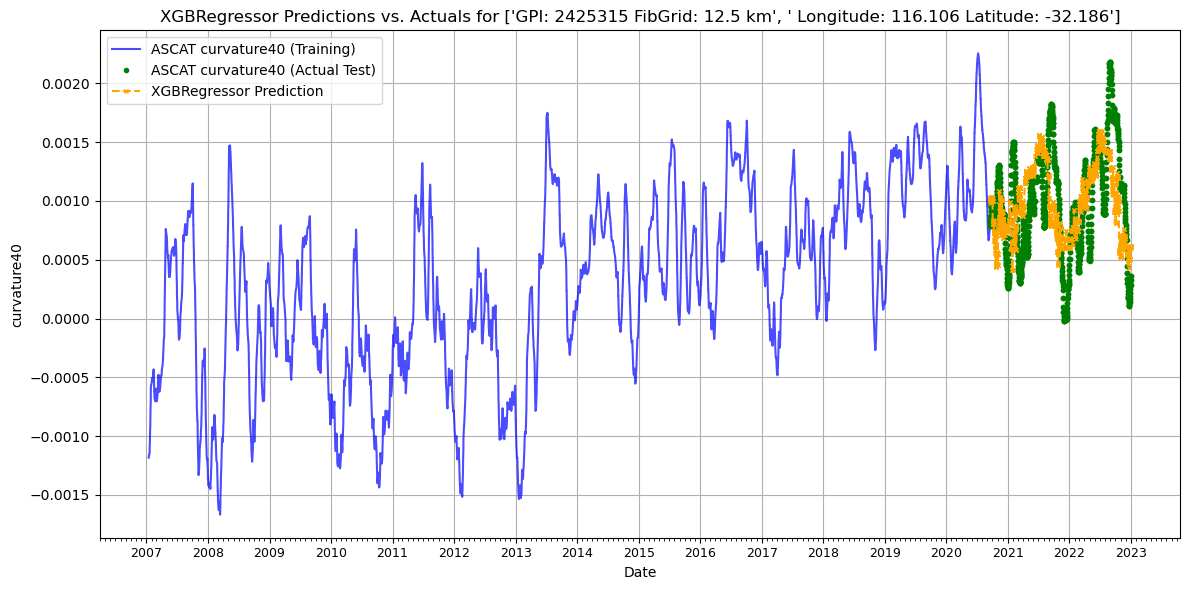

2026-03-17 00:15:21,071 - Starting expanding window forecast for 2264 points...
2026-03-17 00:15:31,249 - -- 4% done
2026-03-17 00:15:41,520 - -- 9% done
2026-03-17 00:15:51,948 - -- 13% done
2026-03-17 00:16:02,326 - -- 18% done
2026-03-17 00:16:13,063 - -- 22% done
2026-03-17 00:16:24,723 - -- 27% done
2026-03-17 00:16:36,435 - -- 31% done
2026-03-17 00:16:48,171 - -- 35% done
2026-03-17 00:17:00,013 - -- 40% done
2026-03-17 00:17:11,312 - -- 44% done
2026-03-17 00:17:23,173 - -- 49% done
2026-03-17 00:17:35,131 - -- 53% done
2026-03-17 00:17:47,139 - -- 57% done
2026-03-17 00:17:58,339 - -- 62% done
2026-03-17 00:18:09,203 - -- 66% done
2026-03-17 00:18:21,557 - -- 71% done
2026-03-17 00:18:33,860 - -- 75% done
2026-03-17 00:18:46,138 - -- 80% done
2026-03-17 00:18:58,492 - -- 84% done
2026-03-17 00:19:10,866 - -- 88% done
2026-03-17 00:19:23,263 - -- 93% done
2026-03-17 00:19:35,262 - -- 97% done
2026-03-17 00:19:43,440 - -- 100% done
2026-03-17 00:19:43,450 - Expanding window pred

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2425315/gpi_curvature40_expanding_window.png


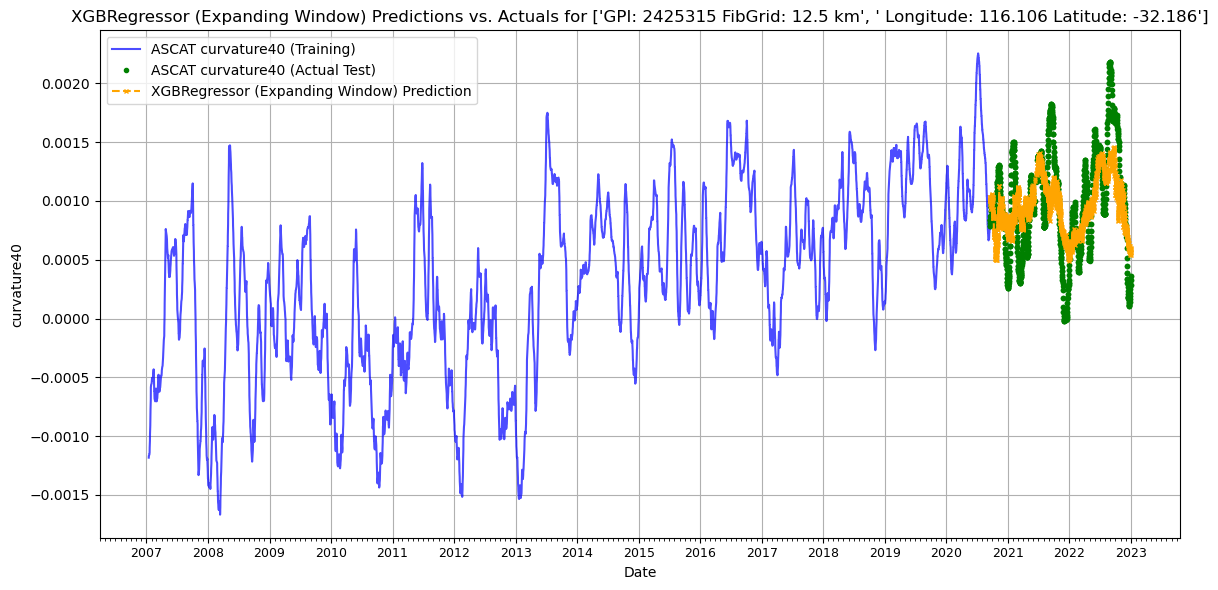

2026-03-17 00:19:44,274 - 
Final Performance:
2026-03-17 00:19:44,275 - RMSE: 0.00036 | MAE: 0.00029 | R2: 0.36827
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-17 00:19:47,581 - gpi: 2298437, lat: -37.55928421020508, lon: 146.19300842285156
2026-03-17 00:19:47,595 - Training data size: 9673
2026-03-17 00:19:47,595 - Testing data size: 2419
2026-03-17 00:19:47,599 - 
--- Baseline Model Performance ---
2026-03-17 00:19:47,606 - 
Climatology Model (Monthly Average):
2026-03-17 00:19:47,606 -   RMSE: 0.00034
2026-03-17 00:19:47,607 -   MAE: 0.00029
2026-03-17 00:19:47,607 -   R2: -0.18479
2026-03-17 00:19:47,608 -   Temporal Correlation: -0.06271
2026-03-17 00:19:47,610 - 
Random Noise Baseline:
2026-03-17 00:19:47,610 -   RMSE: 0.00044
2026-03-17 00:19:47,610 -   MAE: 0.00035
2026-03-17 

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2298437/gpi_curvature40.png


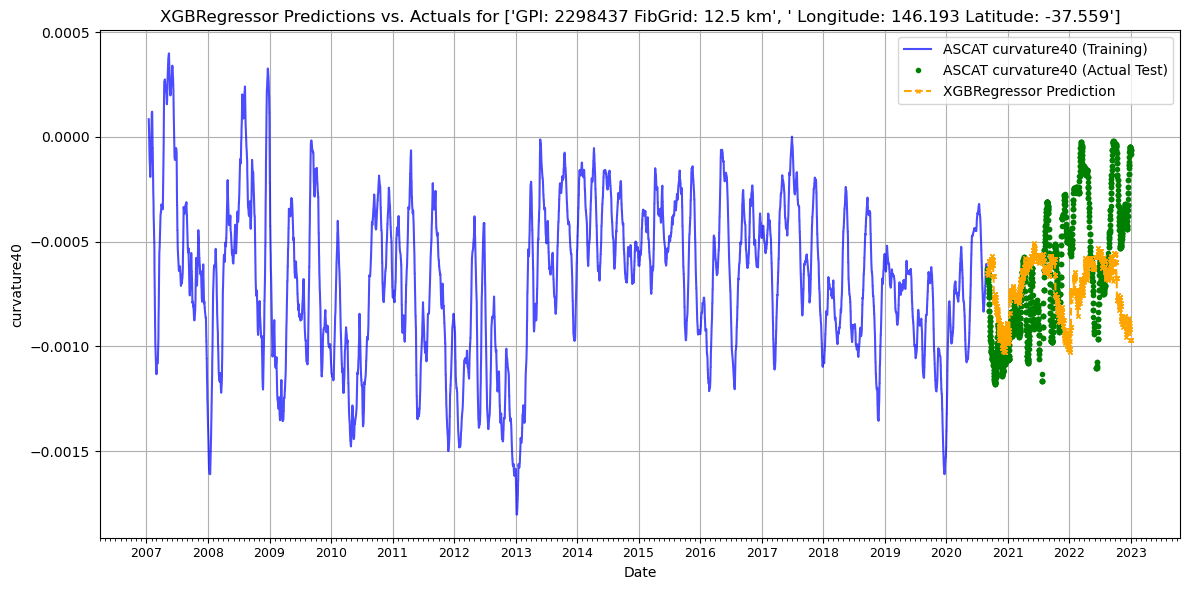

2026-03-17 00:23:46,381 - Starting expanding window forecast for 2419 points...
2026-03-17 00:23:51,947 - -- 4% done
2026-03-17 00:23:57,520 - -- 8% done
2026-03-17 00:24:03,121 - -- 12% done
2026-03-17 00:24:08,728 - -- 17% done
2026-03-17 00:24:14,459 - -- 21% done
2026-03-17 00:24:20,185 - -- 25% done
2026-03-17 00:24:25,928 - -- 29% done
2026-03-17 00:24:31,683 - -- 33% done
2026-03-17 00:24:37,432 - -- 37% done
2026-03-17 00:24:43,252 - -- 41% done
2026-03-17 00:24:49,099 - -- 45% done
2026-03-17 00:24:54,968 - -- 50% done
2026-03-17 00:25:00,878 - -- 54% done
2026-03-17 00:25:06,797 - -- 58% done
2026-03-17 00:25:12,736 - -- 62% done
2026-03-17 00:25:18,716 - -- 66% done
2026-03-17 00:25:24,405 - -- 70% done
2026-03-17 00:25:30,029 - -- 74% done
2026-03-17 00:25:36,107 - -- 79% done
2026-03-17 00:25:42,150 - -- 83% done
2026-03-17 00:25:47,835 - -- 87% done
2026-03-17 00:25:53,427 - -- 91% done
2026-03-17 00:25:59,541 - -- 95% done
2026-03-17 00:26:05,724 - -- 99% done
2026-03-17

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2298437/gpi_curvature40_expanding_window.png


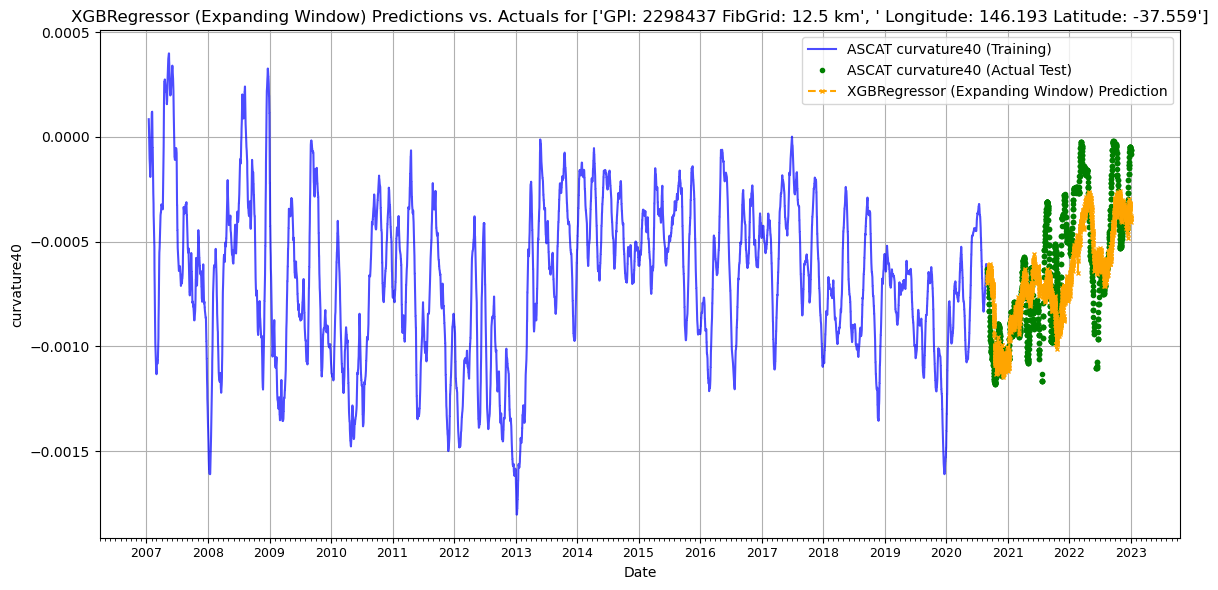

2026-03-17 00:26:07,611 - 
Final Performance:
2026-03-17 00:26:07,612 - RMSE: 0.00021 | MAE: 0.00016 | R2: 0.56573
/home/jovyan/SCAT_Data_Science/.conda_envs/scat_ds_env/lib/python3.12/site-packages/pynetcf/time_series.py:526: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  return self.variables[var][index]
2026-03-17 00:26:12,201 - gpi: 2848274, lat: -15.99067211151123, lon: 129.7310333251953
2026-03-17 00:26:12,213 - Training data size: 7908
2026-03-17 00:26:12,214 - Testing data size: 1977
2026-03-17 00:26:12,217 - 
--- Baseline Model Performance ---
2026-03-17 00:26:12,224 - 
Climatology Model (Monthly Average):
2026-03-17 00:26:12,224 -   RMSE: 0.00093
2026-03-17 00:26:12,224 -   MAE: 0.00072
2026-03-17 00:26:12,225 -   R2: 0.58134
2026-03-17 00:26:12,225 -   Temporal Correlation: 0.81559
2026-03-17 00:26:12,228 - 
Random Noise Baseline:
2026-03-17 00:26:12,228 -   RMSE: 0.00198
2026-03-17 00:26:12,229 -   MAE: 0.00152
2026-03-17 00:

Plot saved to: ./images/curvature_no_backscatter/lagged/Australia_2848274/gpi_curvature40.png


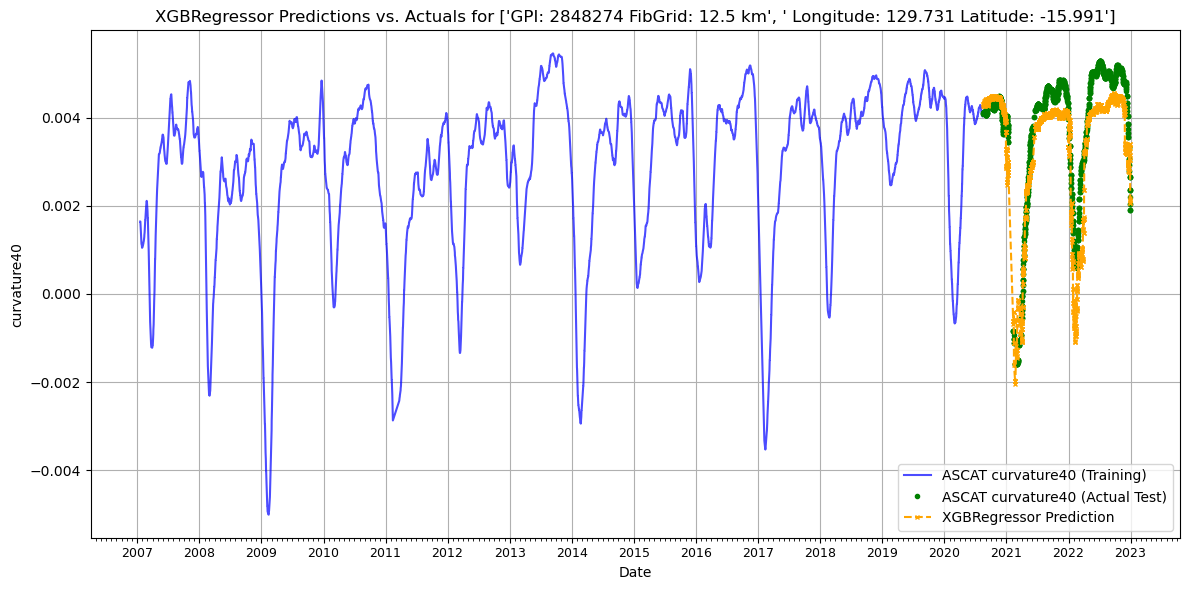

2026-03-17 00:29:49,401 - Starting expanding window forecast for 1977 points...
2026-03-17 00:30:08,496 - -- 5% done
2026-03-17 00:30:27,683 - -- 10% done
2026-03-17 00:30:46,829 - -- 15% done


In [ ]:
australia_border_gpis = [2891016, 2866040, 2831296, 2912599, 2808396,
                         2718799, 2606988, 2618866, 2515328, 2395765,
                         2303173, 2326162, 2690836, 2576119, 2379934, 
                         2402792, 2485019, 2425315, 2298437, 2848274]

australia_middle_gpis = [2531738, 2535275, 2683385, 2717100, 2687346,
                         2601807, 2664556, 2551936, 2411002, 2505788,
                         2579593, 2639059, 2620149, 2504225]

gpis = australia_border_gpis+australia_middle_gpis
ROOT_OUTPUT_DIR = "./images/curvature_no_backscatter/lagged"

for target_column in ["curvature40"]:
    logging.info(f"Modelling {target_column}")
    for gpi in gpis:
        ts, loc_info, gpi_info = read_data(gpi)
        logging.info(f"gpi: {gpi}, lat: {gpi_info['lat']}, lon: {gpi_info['lon']}")
        # simple_plot(ts, loc_info, [target_column, "LAI"])
        # logging.info(ts.columns)
        ts = ts[[target_column, "swvl1", "stl1", "tp", "LAI"]]
        ts.dropna(inplace=True)
        X = ts[["swvl1", "stl1", "tp", "LAI"]]
        y = ts[target_column]
        y = y.loc[X.index]
        lag_days = [7, 14]  # experiment with these
        lag_cols = ["swvl1", "stl1", "tp", "LAI"]  # which features to lag
        X = add_lag_features(X, lag_days=lag_days, lag_cols=lag_cols)
        X.dropna(inplace=True)
        y = y.loc[X.index]
        try:
            # 1. Add temporal variables
            X['year'] = X.index.year
            days_in_year = 365.25  # 365.25 to account for leap years
            X['sin_day'] = np.sin(2 * np.pi * X['day_of_year'] / days_in_year)
            X['cos_day'] = np.cos(2 * np.pi * X['day_of_year'] / days_in_year)
            start_date = X.index.min()
            X['time_step'] = (X.index - start_date).total_seconds() / (24 * 3600)  # days since start       
            # logging.info(f"New feature set columns: {X.columns.tolist()}")

            # 2. Train-Test Split (Time-based)
            split_idx = int(len(X) * 0.8)
            X_train_final, X_test_final = X.iloc[:split_idx], X.iloc[split_idx:]
            y_train_final, y_test_final = y.iloc[:split_idx], y.iloc[split_idx:]

            logging.info(f"Training data size: {len(X_train_final)}")
            logging.info(f"Testing data size: {len(X_test_final)}")

            # 3. Feature Scaling
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_final)
            X_test_scaled = scaler.transform(X_test_final)

            # Convert scaled arrays back to DataFrame to retain column names
            X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_final.columns, index=X_train_final.index)
            X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_final.columns, index=X_test_final.index)

            # 4. Baseline Models for Performance Comparison
            logging.info("\n--- Baseline Model Performance ---")

            # Climatology Model (Monthly Average from Training Data)
            y_train_month_avg = y_train_final.groupby(y_train_final.index.month).mean()
            y_pred_climatology = y_test_final.index.map(lambda x: y_train_month_avg.get(x.month, np.nan))
            y_pred_climatology = pd.Series(y_pred_climatology, index=y_test_final.index)

            rmse_climatology = np.sqrt(mean_squared_error(y_test_final, y_pred_climatology))
            mae_climatology = mean_absolute_error(y_test_final, y_pred_climatology)
            r2_climatology = r2_score(y_test_final, y_pred_climatology)
            temp_corr_climatology = y_test_final.corr(y_pred_climatology)

            logging.info("\nClimatology Model (Monthly Average):")
            logging.info(f"  RMSE: {rmse_climatology:.5f}")
            logging.info(f"  MAE: {mae_climatology:.5f}")
            logging.info(f"  R2: {r2_climatology:.5f}")
            logging.info(f"  Temporal Correlation: {temp_corr_climatology:.5f}")

            # Random Noise Baseline
            # random predictions with mean and std from test data
            np.random.seed(42)
            y_pred_random = np.random.normal(y_test_final.mean(), y_test_final.std(), len(y_test_final))
            y_pred_random = pd.Series(y_pred_random, index=y_test_final.index)

            rmse_random = np.sqrt(mean_squared_error(y_test_final, y_pred_random))
            mae_random = mean_absolute_error(y_test_final, y_pred_random)
            r2_random = r2_score(y_test_final, y_pred_random)
            temp_corr_random = y_test_final.corr(y_pred_random)

            logging.info("\nRandom Noise Baseline:")
            logging.info(f"  RMSE: {rmse_random:.5f}")
            logging.info(f"  MAE: {mae_random:.5f}")
            logging.info(f"  R2: {r2_random:.5f}")
            logging.info(f"  Temporal Correlation: {temp_corr_random:.5f}")

            results = {}

            tscv = TimeSeriesSplit(n_splits=5)

            logging.info("\n--- Machine Learning Model Performance (with Hyperparameter Tuning) ---")

            best_params_storage = {}

            for model_name, model_info in models.items():
                estimator = model_info["model"]
                param_dist = model_info["params"]

                logging.info(f"\n--- Training {model_name} ---")

                search = BayesSearchCV(
                    estimator=estimator,
                    search_spaces=param_dist,
                    n_iter=50,
                    cv=tscv,
                    scoring='neg_root_mean_squared_error', 
                    verbose=0, 
                    n_jobs=-1, 
                    random_state=42
                )

                # Fit scaled training data
                search.fit(X_train_scaled_df, y_train_final)
                # Store best parameters
                best_params_storage[model_name] = search.best_params_

                best_model = search.best_estimator_      
                logging.info(f"Best parameters for {model_name}: {search.best_params_}")
                logging.info(f"Best cross-validation RMSE for {model_name}: {-search.best_score_:.4f}")

                # Predict on test set using best model
                y_pred = best_model.predict(X_test_scaled_df)
                y_pred_series = pd.Series(y_pred, index=y_test_final.index)

                # Evaluate
                rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_series))
                mae = mean_absolute_error(y_test_final, y_pred_series)
                r2 = r2_score(y_test_final, y_pred_series)
                temp_corr = y_test_final.corr(y_pred_series)

                results[model_name] = {
                    "best_params": search.best_params_,
                    "test_rmse": rmse,
                    "test_mae": mae,
                    "test_r2": r2,
                    "test_temporal_correlation": temp_corr,
                    "predictions": y_pred_series
                }

                logging.info("-- Initial Scores --")
                logging.info(f"RMSE: {rmse:.5f}, MAE: {mae:.5f}, R2: {r2:.5f}")

                # Plotting predictions vs actuals for each model
                folder_name = f"Australia_{gpi}"
                output_dir = f"{ROOT_OUTPUT_DIR}/{folder_name}"
                os.makedirs(output_dir, exist_ok=True)
                
                # Feature Importance
                logging.info(f"\n--- Feature Importance for {model_name} ---")
                logging.info("Feature Importance from Shap")
                explainer = shap.TreeExplainer(best_model)
                shap_values = explainer.shap_values(X_test_scaled_df)
                shap.summary_plot(shap_values, X_test_scaled_df, show=False)
                plt.savefig(f"{output_dir}/gpi_{gpi}_{model_name}_shap.png", bbox_inches='tight', dpi=150)
                plt.close() 
                shap_importance = pd.DataFrame(
                    np.abs(shap_values).mean(axis=0),
                    index=X_test_scaled_df.columns,
                    columns=["mean_abs_shap"]
                ).sort_values("mean_abs_shap", ascending=False)               
                logging.info(shap_importance)
                
                # Save initial model predictions
                with open(f"{output_dir}/gpi_{gpi}_initial_predictions.pkl", "wb") as f:
                    pickle.dump({
                        "y_train": y_train_final,
                        "y_test": y_test_final,
                        "results": {m: {"predictions": results[m]["predictions"],
                                        "metrics": {k: v for k, v in results[m].items() if k != "predictions"}}
                                    for m in results}
                    }, f)
                logging.info(f"Initial predictions saved to {output_dir}/gpi_{gpi}_initial_predictions.pkl")         
                prediction_plot(model_name, target_column, y_train_final, y_test_final, y_pred_series, save_path=f"{output_dir}/gpi_{target_column}.png")

            best_params_rf = best_params_storage["XGBRegressor"]

            n_test_points = len(X) - int(len(X) * 0.8)
            tscv = TimeSeriesSplit(n_splits=n_test_points, test_size=1)

            all_preds = []
            all_actuals = []
            all_indices = []

            logging.info(f"Starting expanding window forecast for {n_test_points} points...")

            for i, (train_index, test_index) in enumerate(tscv.split(X)):
                # Split the data
                X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                y_train, y_test = y.iloc[train_index], y.iloc[test_index]

                model = XGBRegressor(**best_params_rf)
                model.fit(X_train, y_train)

                pred = model.predict(X_test)

                all_preds.append(pred[0])
                all_actuals.append(y_test.values[0])
                all_indices.append(y_test.index[0])
                # Progress tracking
                if (i + 1) % 100 == 0 or (i + 1) == n_test_points:
                    logging.info(f"-- {round(((i + 1) / n_test_points) * 100)}% done")

            # 6. Evaluation
            rolling_rmse = np.sqrt(mean_squared_error(all_actuals, all_preds))
            rolling_mae = mean_absolute_error(all_actuals, all_preds)
            rolling_r2 = r2_score(all_actuals, all_preds)

            expanding_window_results = {
                "predictions": pd.Series(all_preds, index=all_indices),
                "actuals": pd.Series(all_actuals, index=all_indices),
                "metrics": {"rmse": rolling_rmse, "mae": rolling_mae, "r2": rolling_r2}
            }
            with open(f"{output_dir}/gpi_{gpi}_expanding_window_predictions.pkl", "wb") as f:
                pickle.dump(expanding_window_results, f)
            logging.info(f"Expanding window predictions saved to {output_dir}/gpi_{gpi}_expanding_window_predictions.pkl")
            prediction_plot(
                "XGBRegressor (Expanding Window)",
                target_column,
                y_train_final,
                expanding_window_results["actuals"],
                expanding_window_results["predictions"],
                save_path=f"{output_dir}/gpi_{target_column}_expanding_window.png"
            )
            logging.info("\nFinal Performance:")
            logging.info(f"RMSE: {rolling_rmse:.5f} | MAE: {rolling_mae:.5f} | R2: {rolling_r2:.5f}")

        except Exception as e:
            logging.error(e)
            # modelling error, skip gpi and continue with next one
            continue


In [6]:
print(shap_values.shape)          # should be (n_samples, n_features)
print(np.abs(shap_values).sum())  # if ~0, model is predicting near-constant
print(best_model.feature_importances_)  # XGB's built-in — if also 0, model didn't learn

(2311, 16)
0.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [11]:
print(f"{len(X_train_scaled_df)} \n {len(X_test_scaled_df)}")

9243 
 2311


# TODO:



robust scaler statt standardscaler -> probleme beim mlp  
n_iter im RandomizedSearchCV von 25 erhöhen: nichts gebracht  
Bayesian optimization: einiges gebracht -> jetzt sogar minimal besser als climatologie  
sliding window validation: 150 und 365 Tage haben es schlechter gemacht -> Expanding Window war besser  
train set größer machen und test set kleiner machen hilft auch ein bissl bei RMSE und MAE, aber R2 wird dafür schlechter  
Zeitvariablen hinzufügen -> um einiges besser als klimatologie  

Clustering Algorithms für e.g. feature dependence und je nachdem wo ähnline feature dependency auf gleiches model?

für verschiedene Regionen auf der Erde:

Für slope und curvature:
    o) Preprocessing? outier handling statt dropna() oder median filtering, target lag, feature lag, month variable (hab nur year), vll year und timestep raus weils auf 0 ist in der feature importance
    o) Feature Importance pro Region rausfinden
    o) nur mit besten Featuren probieren